# Host Classification
- Class-Conditional Validity Envelopes - Rather than constructing a single 35-dimensional envelope  
- No Imputation
- No Empty Sets

In [1]:
import os
import pickle
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

### Loading the Data

In [2]:
DATA_DIR = "../Data"
SCORES_PATH = f"{DATA_DIR}/phage_host_scores.parquet"
METADATA_PATH = f"{DATA_DIR}/metadata.csv"
alpha = 0.1

print("Loading phage-level host scores...")
t0 = time.time()
phage_scores = pd.read_parquet(SCORES_PATH)
print(f"  shape : {phage_scores.shape}  ({time.time()-t0:.1f}s)")

print("Loading metadata...")
meta_df = pd.read_csv(METADATA_PATH, index_col="proteinID")
# One row per phage: take first protein's metadata per accession
phage_meta = (meta_df.reset_index().groupby("accession")[["host", "host_type", "split"]].first())
print(f"  phage_meta shape : {phage_meta.shape}")

Loading phage-level host scores...
  shape : (18443, 2036)  (0.6s)
Loading metadata...
  phage_meta shape : (18474, 3)


#### Joining scores with labels

In [3]:
phage_df = phage_scores.join(phage_meta, how="inner")
phage_df["split"] = phage_df["split"].astype(int)

print(f"\nPhage-level shape after join: {phage_df.shape}")
print("\nSplit distribution:")
print(phage_df["split"].value_counts().sort_index())
print("\nHost distribution (top 15):")
print(phage_df["host"].value_counts().head(15))


Phage-level shape after join: (18443, 2039)

Split distribution:
split
0    4422
1    3169
2    3638
3    3584
4    3630
Name: count, dtype: int64

Host distribution (top 15):
host
Mycobacterium     2352
Escherichia       2254
Pseudomonas       1023
Klebsiella         966
Salmonella         958
Vibrio             917
Streptococcus      740
Gordonia           657
Staphylococcus     652
Microbacterium     545
Bacillus           440
Ralstonia          412
Arthrobacter       397
Synechococcus      392
Lactococcus        388
Name: count, dtype: int64


#### Identifying the score columns and host 

In [4]:
score_cols = [c for c in phage_scores.columns]

# Host genus = prefix before first underscore
all_hosts = sorted(set(c.split("_")[0] for c in score_cols))
print(f"Host: {len(all_hosts)}")
print(all_hosts)

# Map each host to its column indices
host_col_map = {h: [i for i, c in enumerate(score_cols) if c.split("_")[0] == h] for h in all_hosts}
print("\nColumns per host (sample):")
for h in all_hosts:
    print(f"  {h}: {len(host_col_map[h])} columns")

Host: 54
['Campylobacter', 'Caulobacter', 'Cellulophaga', 'Citrobacter', 'Clostridioides', 'Clostridium', 'Corynebacterium', 'Cronobacter', 'Dickeya', 'Edwardsiella', 'Enterobacter', 'Enterococcus', 'Erwinia', 'Escherichia', 'Flavobacterium', 'Gordonia', 'Haloarcula', 'Halorubrum', 'Klebsiella', 'Lacticaseibacillus', 'Lactobacillus', 'Lactococcus', 'Listeria', 'Microbacterium', 'Microcystis', 'Mycobacterium', 'Paenibacillus', 'Pantoea', 'Pectobacterium', 'Pelagibacter', 'Prochlorococcus', 'Propionibacterium', 'Proteus', 'Providencia', 'Pseudoalteromonas', 'Pseudomonas', 'Ralstonia', 'Rhizobium', 'Rhodobacter', 'Roseobacter', 'Salmonella', 'Serratia', 'Shewanella', 'Shigella', 'Sinorhizobium', 'Staphylococcus', 'Stenotrophomonas', 'Streptococcus', 'Streptomyces', 'Sulfolobus', 'Synechococcus', 'Vibrio', 'Xanthomonas', 'Yersinia']

Columns per host (sample):
  Campylobacter: 40 columns
  Caulobacter: 40 columns
  Cellulophaga: 36 columns
  Citrobacter: 40 columns
  Clostridioides: 36 col

### Train Test Split

In [5]:
phage_df = phage_df[phage_df["host"].isin(all_hosts)].copy()

train_df = phage_df[phage_df["split"] != 0].copy()
test_df = phage_df[phage_df["split"] == 0].copy()

print(f"Training phages (folds 1-4) : {len(train_df)}")
print(f"Test phages     (fold 0)    : {len(test_df)}")
print(f"\nTest host distribution:")
print(test_df["host"].value_counts())

Training phages (folds 1-4) : 11694
Test phages     (fold 0)    : 3944

Test host distribution:
host
Escherichia           856
Mycobacterium         497
Vibrio                279
Staphylococcus        235
Pseudomonas           196
Ralstonia             183
Salmonella            182
Klebsiella            168
Synechococcus         168
Streptococcus         160
Microbacterium        123
Propionibacterium     106
Gordonia               81
Enterococcus           72
Sulfolobus             55
Lactococcus            51
Shigella               46
Erwinia                38
Pelagibacter           31
Clostridium            29
Halorubrum             28
Flavobacterium         28
Yersinia               27
Streptomyces           22
Lactobacillus          21
Caulobacter            20
Rhizobium              19
Listeria               17
Cronobacter            16
Roseobacter            15
Enterobacter           15
Serratia               15
Pseudoalteromonas      14
Haloarcula             13
Corynebacterium

### Score characteristics
 -  For each host, the columns specific to that host should have higher mean scores for phages that actually infect that host.

In [6]:
print("Mean score at true-host columns vs all columns (training set):")
sample_hosts = all_hosts[:5]
for h in sample_hosts:
    h_idx = host_col_map[h]
    mask_h = train_df["host"] == h
    if mask_h.sum() == 0:
        continue
    true_host_mean = np.nanmean(train_df.loc[mask_h, score_cols].values[:, h_idx])
    all_mean = np.nanmean(train_df.loc[mask_h, score_cols].values)
    print(f"  {h}: true-host cols mean={true_host_mean:.3f}, "
          f"all cols mean={all_mean:.3f}, n={mask_h.sum()}")

Mean score at true-host columns vs all columns (training set):
  Campylobacter: true-host cols mean=0.207, all cols mean=0.052, n=96
  Caulobacter: true-host cols mean=0.271, all cols mean=0.058, n=31
  Cellulophaga: true-host cols mean=0.262, all cols mean=0.051, n=45
  Citrobacter: true-host cols mean=0.072, all cols mean=0.053, n=39
  Clostridioides: true-host cols mean=0.368, all cols mean=0.091, n=17


### Score Transformation
 -  For host classification: NC = 1 - raw_score
 - High raw score = strong infection evidence = low nonconformity

In [7]:
def raw_to_nc(raw_array):
    return np.where(np.isnan(raw_array), np.nan, 1.0 - raw_array)

train_raw = train_df[score_cols].values   # (n_train, K)
test_raw = test_df[score_cols].values    # (n_test,  K)
train_labels = train_df["host"].to_numpy(dtype=str)
test_labels = test_df["host"].to_numpy(dtype=str)

train_nc = raw_to_nc(train_raw)
test_nc = raw_to_nc(test_raw)

print(f"Train NC shape: {train_nc.shape}")
print(f"Test NC shape : {test_nc.shape}")
print(f"NaN fraction in train NC: {np.isnan(train_nc).mean():.3f}")
print(f"NaN fraction in test NC : {np.isnan(test_nc).mean():.3f}")

Train NC shape: (11694, 2036)
Test NC shape : (3944, 2036)
NaN fraction in train NC: 0.623
NaN fraction in test NC : 0.631


### Functions

In [8]:
def quantile_for_class(tau_scores, labels, cls, alpha):
    vals = np.sort(tau_scores[labels == cls])
    n = len(vals)
    if n == 0:
        return 0.0
    idx = int(np.ceil((n + 1) * (1 - alpha))) - 1
    return vals[np.clip(idx, 0, n - 1)]


def compute_t_hat_multiclass(tau_scores, labels, classes, alpha):
    """t_hat = max over all classes of the per-class (1-alpha) quantile."""
    return max(quantile_for_class(tau_scores, labels, c, alpha) for c in classes)

### 1D Collapsed Envelope

In [9]:
def collapsed_build_envelope(S1, S2, labels_S2, classes, alpha):
    S1_1d = np.nanmean(S1, axis=1, keepdims=True)
    S2_1d = np.nanmean(S2, axis=1, keepdims=True)
    q_tilde = np.nanquantile(S1_1d, 1 - alpha)
    tau_scores = (S2_1d / (q_tilde + 1e-12)).ravel()
    t_hat = compute_t_hat_multiclass(tau_scores, labels_S2, classes, alpha)
    return {"q_tilde": q_tilde, "t_hat": t_hat, "method": "collapsed"}


def collapsed_tau(scores, envelope):
    scores_1d = np.nanmean(scores, axis=1)
    return scores_1d / (envelope["q_tilde"] * envelope["t_hat"] + 1e-12)


def collapsed_is_in_region(scores, envelope):
    return np.nanmean(scores, axis=1) <= envelope["q_tilde"] * envelope["t_hat"]

### Radial Envelope

In [10]:
def sample_positive_sphere(M, K):
    V = np.abs(np.random.randn(M, K))
    return V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-12)


def radial_build_envelope(S1, S2, labels_S2, classes, alpha, M=200, delta_deg=30):
    N1, K = S1.shape
    U = sample_positive_sphere(M, K)
    cos_thresh = np.cos(np.radians(delta_deg))

    mags = np.array([np.linalg.norm(S1[n, ~np.isnan(S1[n])]) for n in range(N1)])
    dirs = np.zeros((N1, K))
    for n in range(N1):
        valid = ~np.isnan(S1[n])
        if mags[n] > 1e-12:
            dirs[n, valid] = S1[n, valid] / mags[n]

    q_tilde = np.zeros(M)
    for m in range(M):
        cos_sims = dirs @ U[m]
        nearby = cos_sims >= cos_thresh
        src_mags = mags[nearby] if nearby.sum() > 5 else mags
        q_tilde[m] = np.quantile(src_mags, 1 - alpha)

    N2 = S2.shape[0]
    tau_scores = np.zeros(N2)
    boundary = U * q_tilde[:, None]
    for n in range(N2):
        valid = ~np.isnan(S2[n])
        if valid.sum() == 0:
            tau_scores[n] = 0.0
            continue
        ratios_m = (S2[n, valid][None, :] /
                    (boundary[:, valid] + 1e-12)).max(axis=1)
        tau_scores[n] = ratios_m.min()

    t_hat = compute_t_hat_multiclass(tau_scores, labels_S2, classes, alpha)
    return {"U": U, "q_tilde": q_tilde, "t_hat": t_hat, "method": "radial"}


def radial_tau(scores, envelope):
    U, q_tilde, t_hat = envelope["U"], envelope["q_tilde"], envelope["t_hat"]
    boundary = U * (q_tilde * t_hat)[:, None]
    N = scores.shape[0]
    tau = np.zeros(N)
    for n in range(N):
        valid = ~np.isnan(scores[n])
        if valid.sum() == 0:
            tau[n] = 0.0
            continue
        ratios_m = (scores[n, valid][None, :] / (boundary[:, valid] + 1e-12)).max(axis=1)
        tau[n] = ratios_m.min()
    return tau


def radial_is_in_region(scores, envelope):
    U, q_tilde, t_hat = envelope["U"], envelope["q_tilde"], envelope["t_hat"]
    boundary = U * (q_tilde * t_hat)[:, None]
    N = scores.shape[0]
    inside = np.zeros(N, dtype=bool)
    for n in range(N):
        valid = ~np.isnan(scores[n])
        if valid.sum() == 0:
            inside[n] = True
            continue
        inside[n] = np.any(np.all(scores[n, valid][None, :] <= boundary[:, valid], axis=1))
    return inside

### Strip Envelope

In [11]:
def strip_shape_discovery(S1, alpha, M):
    N1, K = S1.shape
    bin_edges = np.array([
        np.linspace(np.nanmin(S1[:, j]), np.nanmax(S1[:, j]), M + 1)
        for j in range(K)
    ])
    limits = np.zeros((K, K, M))
    marginal_quantiles = np.array([
        np.nanquantile(S1[:, i], 1 - alpha) for i in range(K)
    ])
    for j in range(K):
        for m in range(M):
            lo, hi = bin_edges[j, m], bin_edges[j, m + 1]
            in_strip = (~np.isnan(S1[:, j])) & (S1[:, j] >= lo) & (S1[:, j] < hi)
            for i in range(K):
                if i == j:
                    continue
                src_mask = in_strip & (~np.isnan(S1[:, i]))
                if src_mask.sum() >= 3:
                    limits[j, i, m] = np.quantile(S1[src_mask, i], 1 - alpha)
                else:
                    non_nan_i = S1[~np.isnan(S1[:, i]), i]
                    limits[j, i, m] = (
                        np.quantile(non_nan_i, 1 - alpha)
                        if len(non_nan_i) > 0 else marginal_quantiles[i]
                    )
    for j in range(K):
        for i in range(K):
            if i == j:
                continue
            for m in range(M - 2, -1, -1):
                limits[j, i, m] = max(limits[j, i, m], limits[j, i, m + 1])
    return bin_edges, limits, marginal_quantiles


def get_bin_indices(scores, bin_edges):
    K = scores.shape[1]
    M = bin_edges.shape[1] - 1
    return np.array([np.clip(np.where(np.isnan(scores[:, j]), 0, np.digitize(scores[:, j], bin_edges[j]) - 1), 0, M - 1) for j in range(K)]).T


def strip_tau_scores(S, bin_edges, limits, marginal_quantiles):
    """Vectorised version — avoids the inner (j, i) Python loop."""
    N, K = S.shape
    bin_idx = get_bin_indices(S, bin_edges)   # (N, K)

    # Advanced indexing with broadcasting directly constructs the (N, K, K) array
    j_idx = np.arange(K)[None, :, None]
    i_idx = np.arange(K)[None, None, :]
    m_idx = bin_idx[:, :, None]
    
    lims = limits[j_idx, i_idx, m_idx]   # (N, K, K)

    S_i = S[:, np.newaxis, :]        # (N, 1, K) — broadcast over j
    S_j = S[:, :, np.newaxis]        # (N, K, 1) — broadcast over i

    nan_i = np.isnan(S_i)  # (N, 1, K)
    nan_j = np.isnan(S_j)  # (N, K, 1)

    mq = marginal_quantiles[np.newaxis, np.newaxis, :]  # (1, 1, K)

    ratio = np.zeros((N, K, K))

    both_avail = (~nan_i) & (~nan_j)   # (N, K, K)
    miss_i = nan_i & (~nan_j)

    # Standard: s_i / lim
    ratio = np.where(both_avail, np.broadcast_to(S_i, (N, K, K)) / (lims + 1e-12), ratio)
    # Missing dim i: marginal / lim
    ratio = np.where(miss_i, np.broadcast_to(mq, (N, K, K)) / (lims + 1e-12), ratio)

    # Zero out diagonal (i == j)
    diag_mask = np.eye(K, dtype=bool)[np.newaxis, :, : ]
    ratio = np.where(diag_mask, 0.0, ratio)

    return ratio.max(axis=(1, 2))


def strip_build_envelope(S1, S2, labels_S2, classes, alpha, M=2):
    bin_edges, limits, marginal_quantiles = strip_shape_discovery(S1, alpha, M)
    tau_scores = strip_tau_scores(S2, bin_edges, limits, marginal_quantiles)
    t_hat = compute_t_hat_multiclass(tau_scores, labels_S2, classes, alpha)
    return {
        "bin_edges": bin_edges,
        "limits": limits,
        "marginal_quantiles": marginal_quantiles,
        "t_hat": t_hat,
        "method": "strip"
    }


def strip_tau(scores, envelope):
    raw = strip_tau_scores(scores, envelope["bin_edges"], envelope["limits"], envelope["marginal_quantiles"])
    return raw / (envelope["t_hat"] + 1e-12)


def strip_is_in_region(scores, envelope):
    tau = strip_tau_scores(scores, envelope["bin_edges"], envelope["limits"], envelope["marginal_quantiles"])
    return tau <= envelope["t_hat"]

In [12]:
def is_in_region(scores, envelope):
    if envelope["method"] == "radial":
        return radial_is_in_region(scores, envelope)
    elif envelope["method"] == "strip":
        return strip_is_in_region(scores, envelope)
    return collapsed_is_in_region(scores, envelope)


def compute_tau(scores, envelope):
    if envelope["method"] == "collapsed":
        return collapsed_tau(scores, envelope)
    elif envelope["method"] == "strip":
        return strip_tau(scores, envelope)
    return radial_tau(scores, envelope)

### Envelope construction
- Building an envelope per host. 
- For each host
    - Extract only the K_h columns specific to host h
    - Build a separate envelope calibrated on training phages with true host h
    - At test time, check each hypothesis h using its K_h-dim NC sub-vector

In [13]:
def build_per_host_envelopes(train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha,
                              method="collapsed", seed=42):
    rng = np.random.default_rng(seed)
    envelopes = {}

    for h in all_hosts:
        h_idx = host_col_map[h]
        if len(h_idx) == 0:
            continue

        mask_h = train_labels == h
        n_h = mask_h.sum()
        if n_h < 6:
            # Too few training phages to split S1/S2 meaningfully
            print(f"  SKIP {h}: only {n_h} training phages")
            continue

        train_nc_h = train_nc[mask_h][:, h_idx]   # (n_h, K_h)

        # 50/50 shuffle split into S1 and S2
        idx = rng.permutation(n_h)
        half = n_h // 2
        S1 = train_nc_h[idx[:half]]
        S2 = train_nc_h[idx[half:]]
        labels_S2 = np.array([h] * len(S2))

        if method == "collapsed":
            env = collapsed_build_envelope(S1, S2, labels_S2, [h], alpha)
        elif method == "radial":
            env = radial_build_envelope(S1, S2, labels_S2, [h], alpha)
        else:
            env = strip_build_envelope(S1, S2, labels_S2, [h], alpha)

        envelopes[h] = {"envelope": env, "col_indices": h_idx}

    print(f"  Built {len(envelopes)} host envelopes")
    return envelopes

### Host prediction

In [14]:
def predict_host(test_raw, per_host_envelopes, all_hosts):
    """
    Vectorised: for each host h, check ALL test phages at once.
    Builds an (N, n_hosts) boolean matrix, then assembles prediction sets.
    """
    N = len(test_raw)
    active_hosts = [h for h in all_hosts if h in per_host_envelopes]
    n_h = len(active_hosts)

    # inside[i, j] = True if phage i is inside host j's envelope
    inside_matrix = np.zeros((N, n_h), dtype=bool)
    tau_matrix = np.zeros((N, n_h), dtype=float)

    for j, h in enumerate(active_hosts):
        h_idx = per_host_envelopes[h]["col_indices"]
        env_h = per_host_envelopes[h]["envelope"]

        # NC sub-vectors for ALL test phages at once — shape (N, K_h)
        raw_h = test_raw[:, h_idx]
        nc_h = np.where(np.isnan(raw_h), np.nan, 1.0 - raw_h)

        inside_matrix[:, j] = is_in_region(nc_h, env_h)
        tau_matrix[:, j] = compute_tau(nc_h, env_h)

    # Assemble results from the matrices
    results = []
    for i in range(N):
        pred_set = [active_hosts[j] for j in range(n_h) if inside_matrix[i, j]]
        forced = False
        if len(pred_set) == 0:
            forced = True
            best_j = int(np.argmin(tau_matrix[i]))
            pred_set = [active_hosts[best_j]]
        results.append({
            "prediction_set": pred_set,
            "forced":         forced,
            "tau_per_host":   {active_hosts[j]: tau_matrix[i, j]
                               for j in range(n_h)}
        })
    return results

#### Evaluation

In [15]:
def evaluate_multiclass(results, true_labels, all_hosts, alpha):
    n = len(results)
    set_sizes = [len(r["prediction_set"]) for r in results]
    covered = sum(
        true_labels[i] in r["prediction_set"] for i, r in enumerate(results)
    )
    forced = sum(r["forced"] for r in results)
    singletons = [(r, true_labels[i]) for i, r in enumerate(results) if len(r["prediction_set"]) == 1]

    correct_singletons = sum(r["prediction_set"][0] == lbl for r, lbl in singletons)

    per_host_coverage = {}
    for h in all_hosts:
        h_idx = [i for i, lbl in enumerate(true_labels) if lbl == h]
        if not h_idx:
            continue
        per_host_coverage[h] = sum(true_labels[i] in results[i]["prediction_set"] for i in h_idx) / len(h_idx)

    return {
        "coverage":           covered / n,
        "avg_set_size":       np.mean(set_sizes),
        "singleton_rate":     len(singletons) / n,
        "singleton_accuracy": (correct_singletons / len(singletons)
                               if singletons else None),
        "forced_rate":        forced / n,
        "set_sizes":          set_sizes,
        "per_host_coverage":  per_host_coverage,
        "min_host_coverage":  min(per_host_coverage.values())
                              if per_host_coverage else None,
    }

### Evaluating on split 0 phages

In [16]:
print("\n" + "="*60)
print(" BUILDING PER-HOST ENVELOPES & TESTING ON SPLIT 0 ")
print("="*60)

# Start with collapsed — fastest, verify correctness first
print("\nBuilding collapsed envelopes...")
t0 = time.time()
per_host_envs_c = build_per_host_envelopes(
    train_nc, train_labels, all_hosts,
    score_cols, host_col_map, alpha,
    method="collapsed", seed=42
)
print(f"  Done ({time.time()-t0:.1f}s)")

print("\nPredicting on split 0...")
t0 = time.time()
collapsed_results = predict_host(test_raw, per_host_envs_c, all_hosts)
print(f"  Done ({time.time()-t0:.1f}s)")

collapsed_metrics = evaluate_multiclass(
    collapsed_results, test_labels, all_hosts, alpha
)

print(f"\n--- COLLAPSED RESULTS ---")
print(f"  Coverage           : {collapsed_metrics['coverage']:.3f}  "
      f"(target >= {1-alpha:.2f})")
print(f"  Avg set size       : {collapsed_metrics['avg_set_size']:.2f}  "
      f"(out of {len(all_hosts)} hosts)")
print(f"  Singleton rate     : {collapsed_metrics['singleton_rate']:.3f}")
print(f"  Singleton accuracy : {collapsed_metrics['singleton_accuracy']}")
print(f"  Forced rate        : {collapsed_metrics['forced_rate']:.3f}")
print(f"  Min per-host cov.  : {collapsed_metrics['min_host_coverage']:.3f}")


 BUILDING PER-HOST ENVELOPES & TESTING ON SPLIT 0 

Building collapsed envelopes...
  Built 54 host envelopes
  Done (0.2s)

Predicting on split 0...
  Done (0.2s)

--- COLLAPSED RESULTS ---
  Coverage           : 0.928  (target >= 0.90)
  Avg set size       : 7.15  (out of 54 hosts)
  Singleton rate     : 0.171
  Singleton accuracy : 0.8696296296296296
  Forced rate        : 0.005
  Min per-host cov.  : 0.000


In [17]:
h = all_hosts[4]
print(f"Host: {h}")
print(f"Number of columns for {h}: {len(host_col_map[h])}")
print(f"Number of training phages for {h}: {(train_labels == h).sum()}")

Host: Clostridioides
Number of columns for Clostridioides: 36
Number of training phages for Clostridioides: 17


#### Evaluating using radial and strip methods

In [18]:
print("\nBuilding radial envelopes...")
t0 = time.time()
per_host_envs_r = build_per_host_envelopes(train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha,
                                           method="radial", seed=42)
print(f"  Done ({time.time()-t0:.1f}s)")

radial_results = predict_host(test_raw, per_host_envs_r, all_hosts)
radial_metrics = evaluate_multiclass(radial_results, test_labels, all_hosts, alpha)


Building radial envelopes...
  Built 54 host envelopes
  Done (1.2s)


In [19]:
print("\nBuilding strip envelopes...")
t0 = time.time()
per_host_envs_s = build_per_host_envelopes(train_nc, train_labels, all_hosts, score_cols, host_col_map, alpha,
                                            method="strip", seed=42)
print(f"  Done ({time.time()-t0:.1f}s)")


Building strip envelopes...
  Built 54 host envelopes
  Done (11.2s)


In [20]:
strip_results = predict_host(test_raw, per_host_envs_s, all_hosts)
strip_metrics = evaluate_multiclass(strip_results, test_labels, all_hosts, alpha)

### Summary

In [21]:
methods_names = ["Radial", "Strip", "Collapsed 1D"]
all_metrics = [radial_metrics, strip_metrics, collapsed_metrics]

rows = []
for name, m in zip(methods_names, all_metrics):
    rows.append({
        "Method":           name,
        "Coverage":         f"{m['coverage']:.3f}",
        "Avg set size":     f"{m['avg_set_size']:.2f}",
        "Singleton rate":   f"{m['singleton_rate']:.3f}",
        "Singleton acc.":   f"{m['singleton_accuracy']:.3f}"
                            if m["singleton_accuracy"] else "N/A",
        "Forced rate":      f"{m['forced_rate']:.3f}",
        "Min host cov.":    f"{m['min_host_coverage']:.3f}"
                            if m["min_host_coverage"] else "N/A",
    })

print("=== DEFINITIVE HELD-OUT TEST RESULTS (FOLD 0) ===")
print(pd.DataFrame(rows).to_string(index=False))

=== DEFINITIVE HELD-OUT TEST RESULTS (FOLD 0) ===
      Method Coverage Avg set size Singleton rate Singleton acc. Forced rate Min host cov.
      Radial    0.937        42.59          0.000            N/A       0.000           N/A
       Strip    0.482        15.84          0.000            N/A       0.000           N/A
Collapsed 1D    0.928         7.15          0.171          0.870       0.005           N/A


### Plots

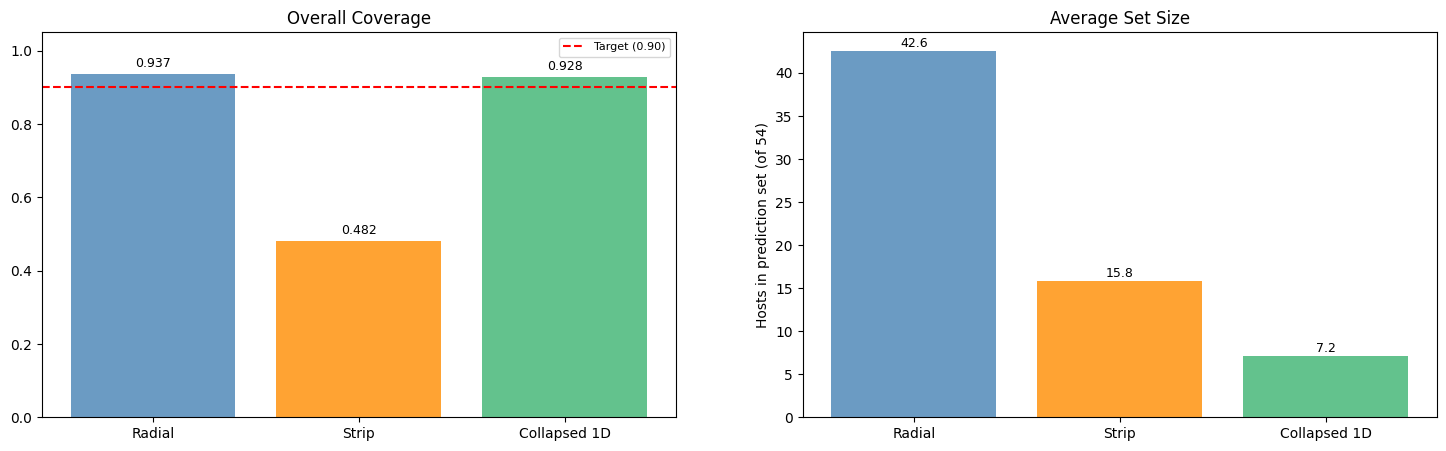

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
colors = ["steelblue", "darkorange", "mediumseagreen"]

# Overall coverage
ax = axes[0]
vals = [m["coverage"] for m in all_metrics]
bars = ax.bar(methods_names, vals, color=colors, alpha=0.8)
ax.axhline(1 - alpha, color="red", linestyle="--",
           label=f"Target ({1-alpha:.2f})")
ax.set_ylim(0, 1.05)
ax.set_title("Overall Coverage")
ax.legend(fontsize=8)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)

# Average set size
ax = axes[1]
vals = [m["avg_set_size"] for m in all_metrics]
bars = ax.bar(methods_names, vals, color=colors, alpha=0.8)
ax.set_title("Average Set Size")
ax.set_ylabel(f"Hosts in prediction set (of {len(all_hosts)})")
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1,
            f"{val:.1f}", ha="center", va="bottom", fontsize=9)

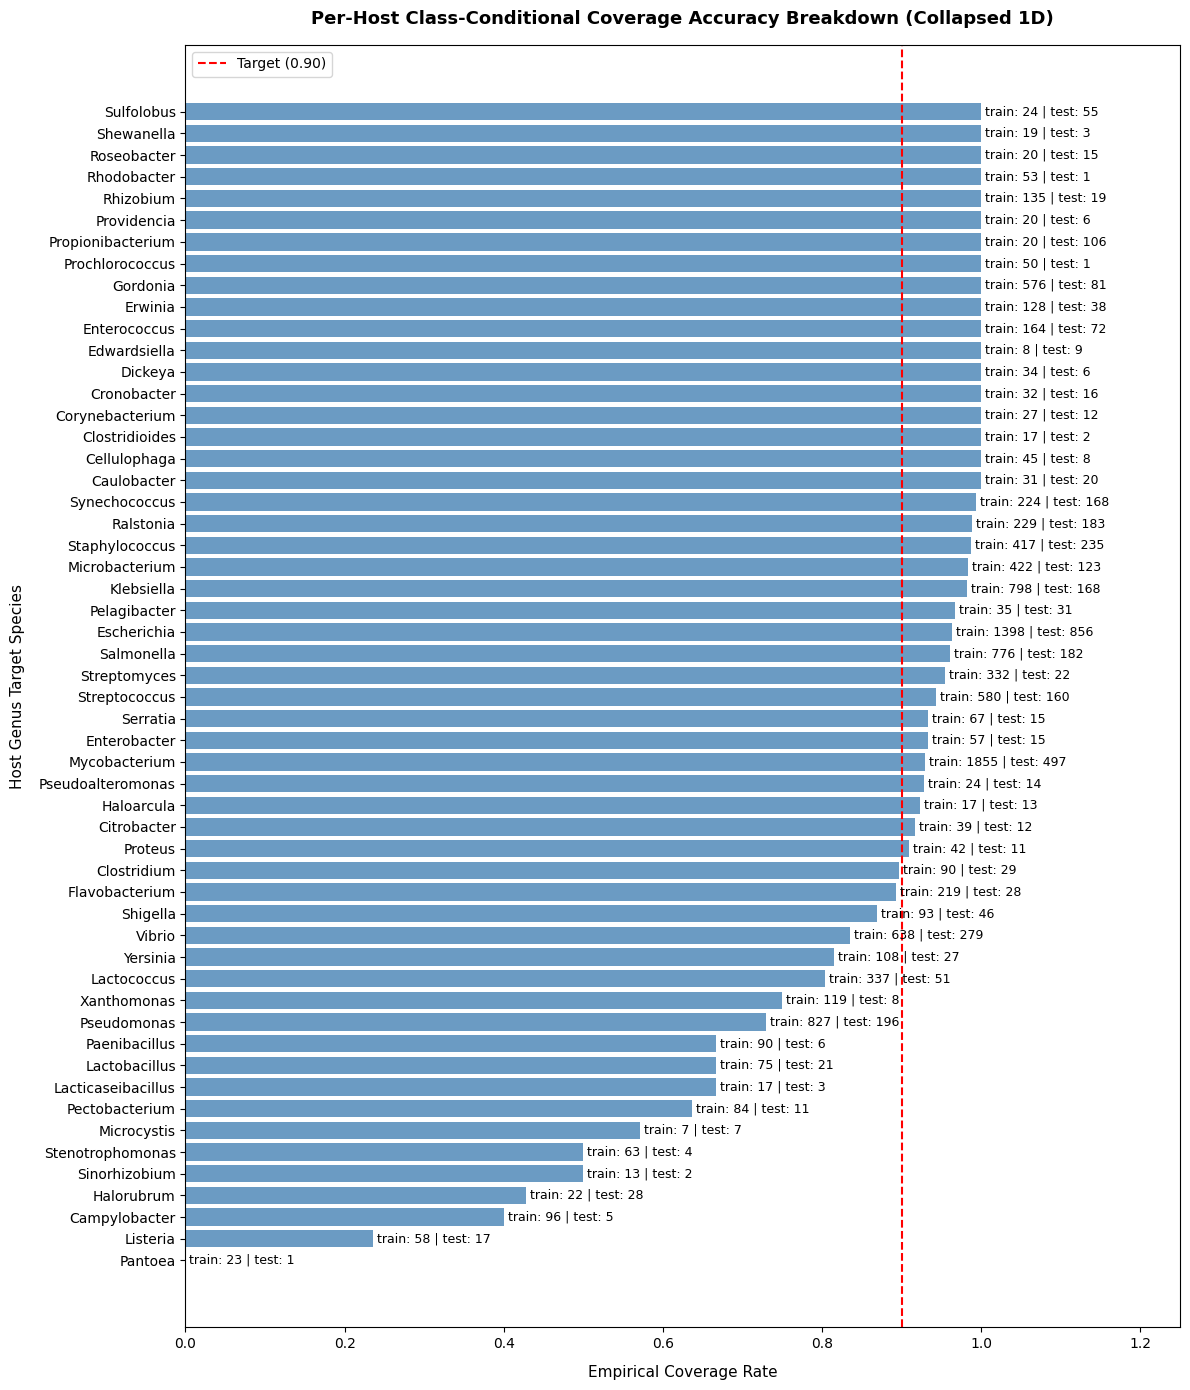

In [23]:
# Grouping train and test data frames by host to get exact phage counts
train_counts = train_df["host"].value_counts().to_dict()
test_counts = test_df["host"].value_counts().to_dict()

host_covs = collapsed_metrics["per_host_coverage"]
hosts_sorted = sorted(host_covs, key=host_covs.get)
vals = [host_covs[h] for h in hosts_sorted]

plt.figure(figsize=(12, 14)) # Slightly widened to ensure text labels fit beautifully
bars = plt.barh(hosts_sorted, vals, color="steelblue", alpha=0.8)
plt.axvline(1 - alpha, color="red", linestyle="--", label=f"Target ({1-alpha:.2f})")

# Loop through each horizontal bar to append custom string metrics
for bar, h in zip(bars, hosts_sorted):
    # Fetch counts safely from dict maps (defaulting to 0 if missing)
    n_train = train_counts.get(h, 0)
    n_test = test_counts.get(h, 0)
    
    # Format the metrics text string
    label_text = f" train: {n_train} | test: {n_test}"
    
    # Place text directly inside/in front of each bar
    # y-coordinate is the center of the bar, x-coordinate is the coverage value
    plt.text(
        x=bar.get_width(), 
        y=bar.get_y() + bar.get_height()/2, 
        s=label_text, 
        va='center', 
        ha='left', 
        fontsize=9, 
        fontweight='medium',
        color='black'
    )

# Formatting labels and clean bounds
plt.xlim(0, 1.25) # Extended limit so the right-side text strings do not clip out of bounds
plt.title("Per-Host Class-Conditional Coverage Accuracy Breakdown (Collapsed 1D)", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Empirical Coverage Rate", fontsize=11, labelpad=10)
plt.ylabel("Host Genus Target Species", fontsize=11, labelpad=10)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()  

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Collect the prediction set sizes tied to their original true host label
# You can swap 'strip_results' with 'collapsed_results' or 'radial_results' depending on the method
results_to_plot = strip_results  

host_set_sizes = []
for i, res in enumerate(results_to_plot):
    host_set_sizes.append({
        "True Host": test_labels[i],
        "Set Size": len(res["prediction_set"])
    })

# Convert to a pandas DataFrame for easier processing/plotting
df_set_sizes = pd.DataFrame(host_set_sizes)

# 2. Calculate summary statistics (Mean, Median, Max) per host sorted by mean size
df_stats = (df_set_sizes.groupby("True Host")["Set Size"]
            .agg(["count", "mean", "median", "min", "max"])
            .reset_index()
            .sort_values(by="mean", ascending=False))

print("=== PER-HOST SET SIZE STATISTICS ===")
print(df_stats.to_string(index=False))

=== PER-HOST SET SIZE STATISTICS ===
         True Host  count      mean  median  min  max
Lacticaseibacillus      3 18.666667    19.0   18   19
   Corynebacterium     12 18.500000    19.0   17   19
     Lactobacillus     21 18.000000    18.0   16   19
   Prochlorococcus      1 18.000000    18.0   18   18
       Lactococcus     51 17.980392    18.0   17   19
        Sulfolobus     55 17.672727    18.0   16   19
     Streptococcus    160 17.500000    18.0   16   19
     Paenibacillus      6 17.333333    18.0   15   18
          Listeria     17 17.294118    18.0   15   19
       Clostridium     29 17.103448    17.0   16   19
        Shewanella      3 17.000000    17.0   16   18
    Clostridioides      2 17.000000    17.0   17   17
    Microbacterium    123 16.821138    17.0   16   18
      Pelagibacter     31 16.806452    17.0   14   19
 Propionibacterium    106 16.650943    17.0   15   17
      Enterococcus     72 16.597222    17.0   15   18
      Streptomyces     22 16.409091    16.0  

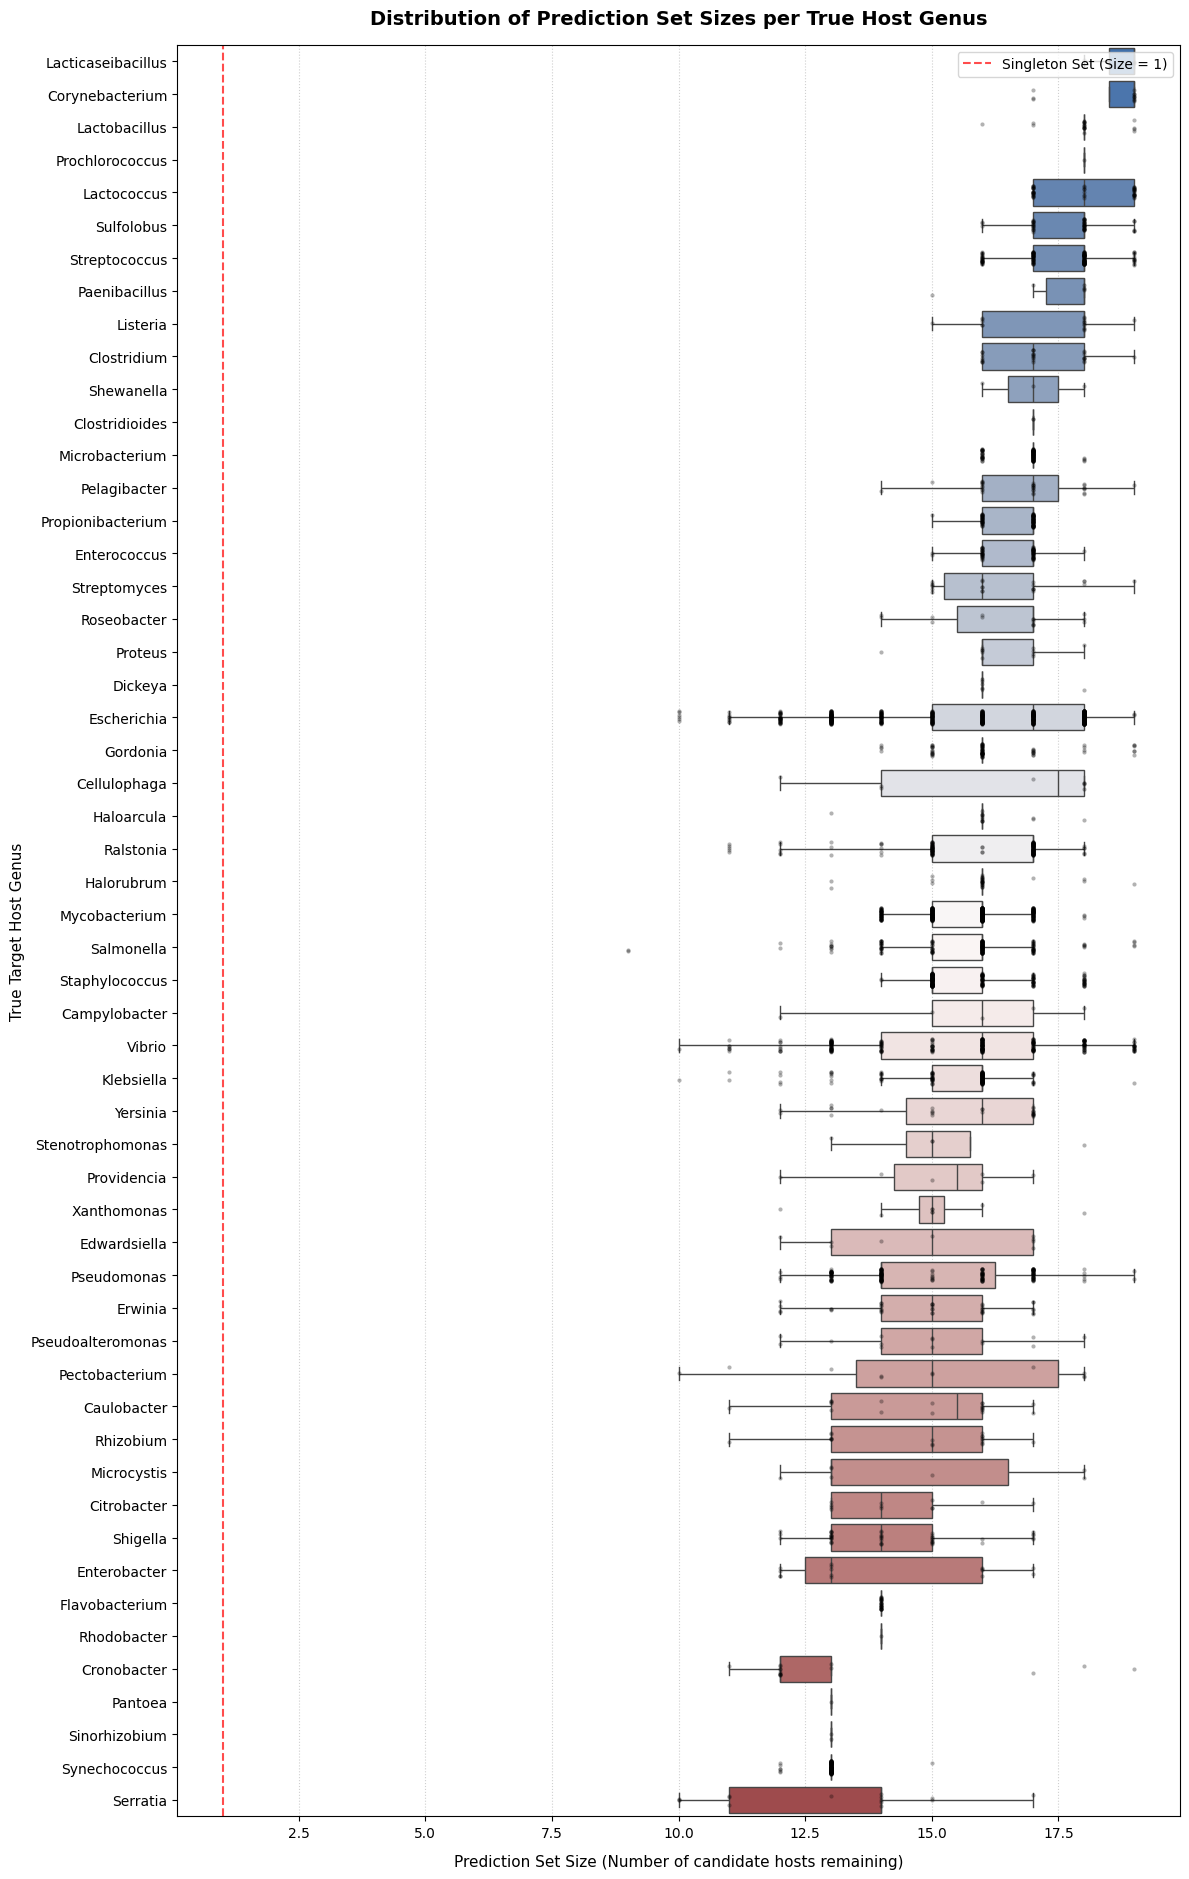

In [25]:
# Setup plot size - dynamic height based on the number of active hosts
unique_test_hosts = df_set_sizes["True Host"].nunique()
plt.figure(figsize=(12, max(6, unique_test_hosts * 0.35)))

# Sort the order of the categorical Y-axis by the average set size calculated above
order = df_stats["True Host"].tolist()

# Create a horizontal boxplot showing the distribution variations
sns.boxplot(
    data=df_set_sizes, 
    x="Set Size", 
    y="True Host", 
    order=order,
    palette="vlag",
    fliersize=0 # hides outliers so they don't overlap with the stripplot
)

# Overlay raw data points slightly jittered to see the sample density per size step
sns.stripplot(
    data=df_set_sizes, 
    x="Set Size", 
    y="True Host", 
    order=order,
    color="black", 
    alpha=0.3, 
    jitter=0.2,
    size=3
)

# Clean up layout, bounds, and titles
plt.axvline(x=1, color="red", linestyle="--", alpha=0.7, label="Singleton Set (Size = 1)")
plt.title("Distribution of Prediction Set Sizes per True Host Genus", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Prediction Set Size (Number of candidate hosts remaining)", fontsize=11, labelpad=10)
plt.ylabel("True Target Host Genus", fontsize=11)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Combine all results into one list
all_data = []

# Map your result lists to their respective envelope method labels
methods_dict = {
    "Collapsed 1D": collapsed_results,
    "Radial": radial_results,
    "Strip": strip_results
}

for method_name, results_list in methods_dict.items():
    for i, res in enumerate(results_list):
        all_data.append({
            "True Host": test_labels[i],
            "Set Size": len(res["prediction_set"]),
            "Envelope Type": method_name
        })

df_all_sets = pd.DataFrame(all_data)

# Calculate overall summary stats to check the average size differences
overall_stats = df_all_sets.groupby("Envelope Type")["Set Size"].agg(["mean", "median", "max"])
print("=== OVERALL SET SIZE COMPARISON ===")
print(overall_stats)

=== OVERALL SET SIZE COMPARISON ===
                    mean  median  max
Envelope Type                        
Collapsed 1D    7.154412     7.0   18
Radial         42.591024    43.0   54
Strip          15.836714    16.0   19


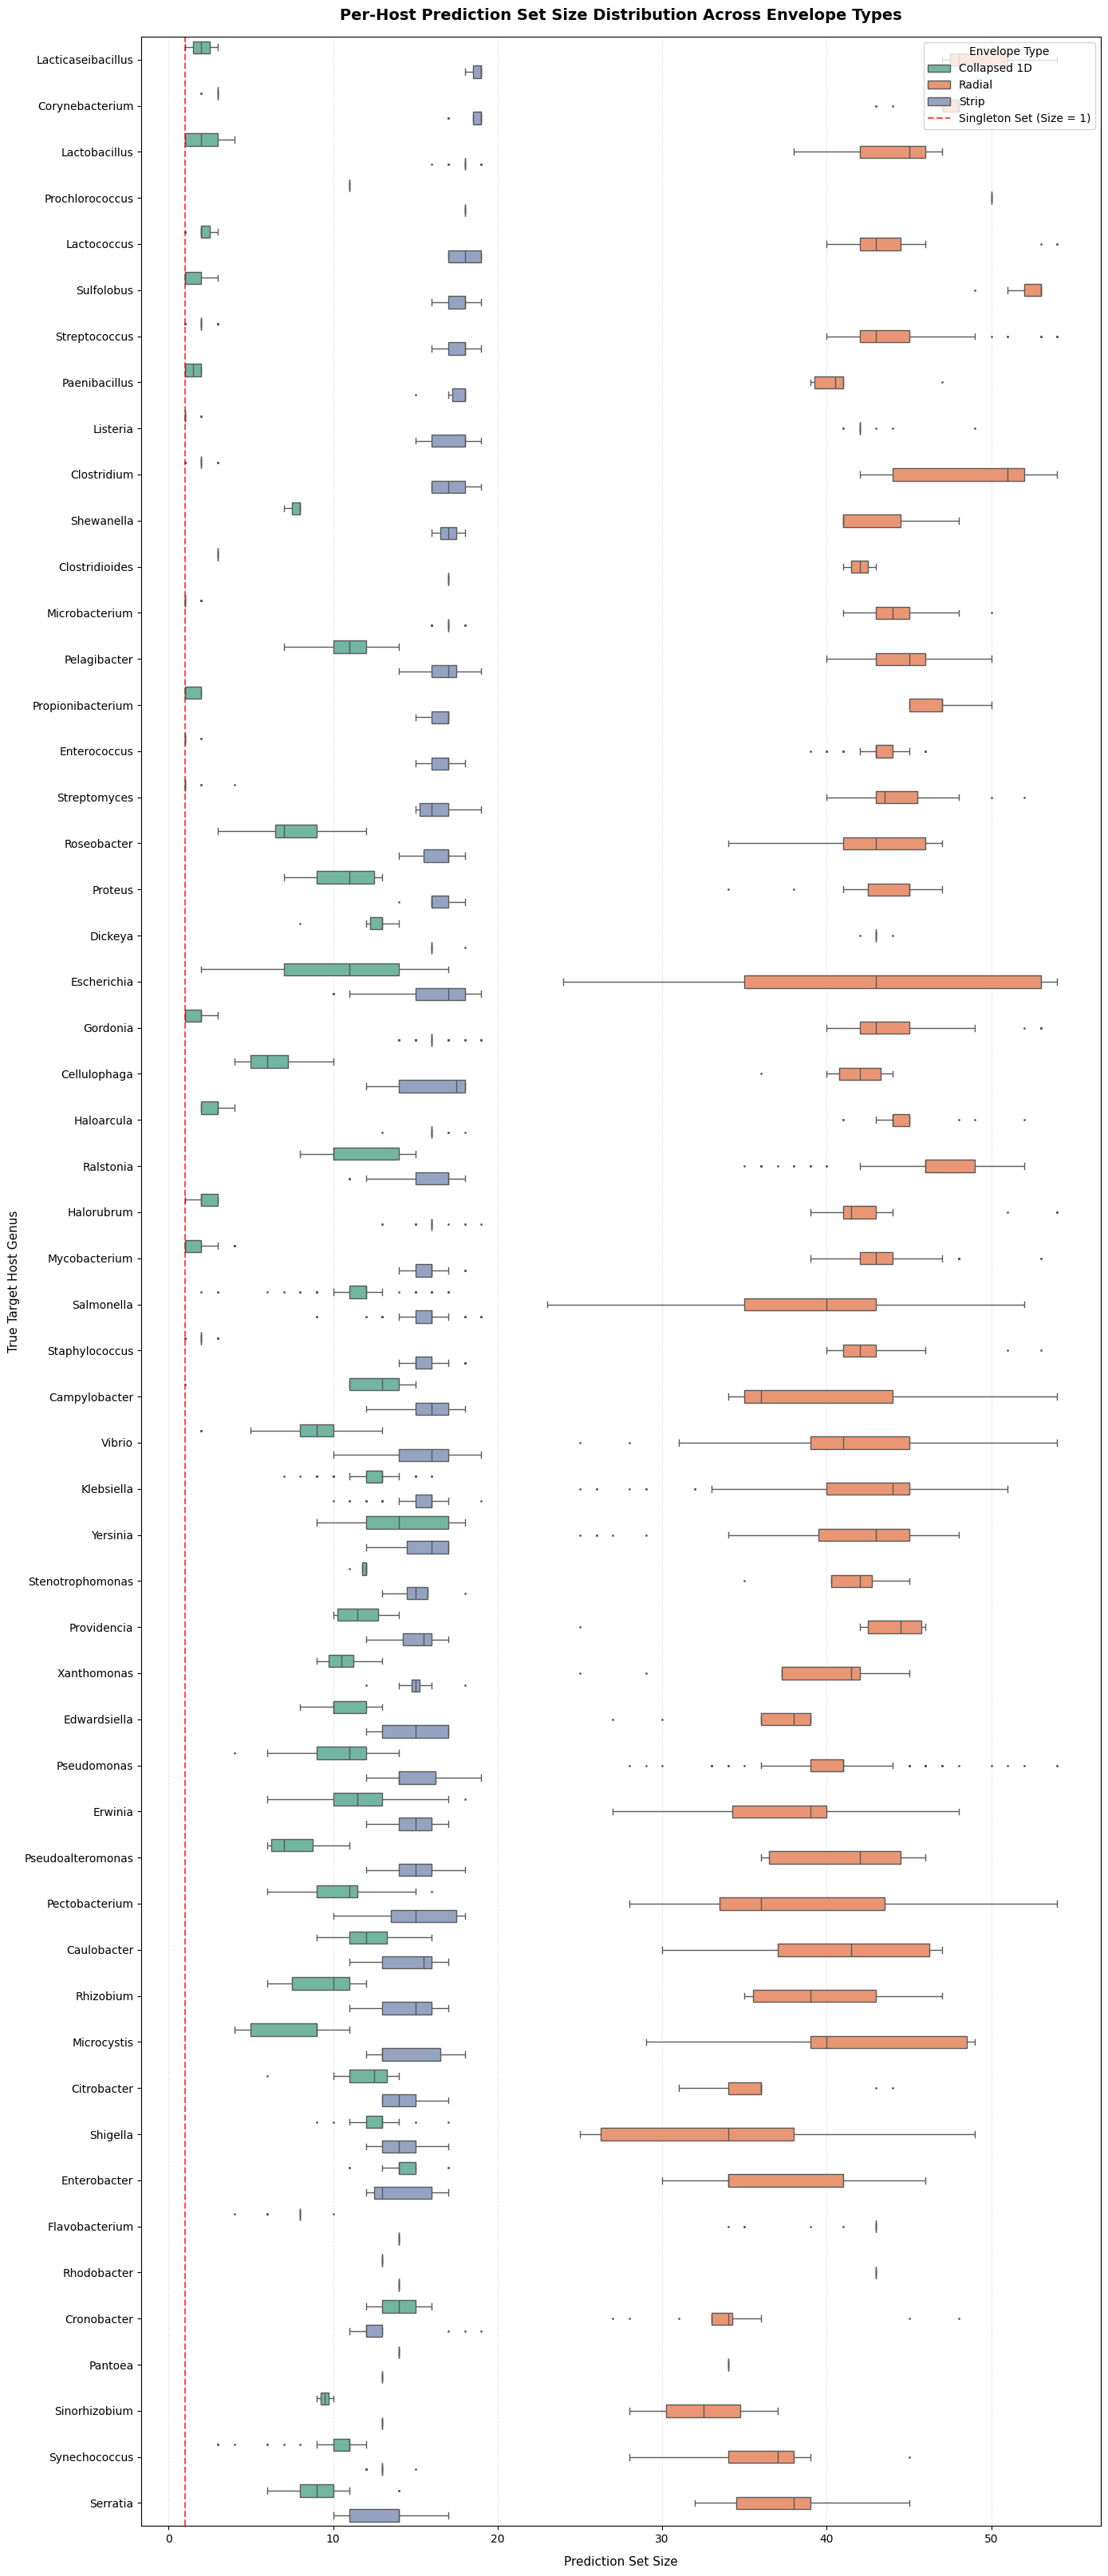

In [27]:
# Order the hosts by the average set size of the Strip envelope to keep the chart organized
strip_host_order = (df_all_sets[df_all_sets["Envelope Type"] == "Strip"]
                    .groupby("True Host")["Set Size"]
                    .mean()
                    .sort_values(ascending=False)
                    .index.tolist())

# Setup dynamic plot height based on unique test hosts
unique_hosts = df_all_sets["True Host"].nunique()
plt.figure(figsize=(14, max(8, unique_hosts * 0.6)))

# Grouped boxplot comparing the three envelope types side-by-side for each host
sns.boxplot(
    data=df_all_sets,
    x="Set Size",
    y="True Host",
    hue="Envelope Type",
    order=strip_host_order,
    palette="Set2",
    fliersize=1  # Small outlier points
)

plt.axvline(x=1, color="red", linestyle="--", alpha=0.7, label="Singleton Set (Size = 1)")
plt.title("Per-Host Prediction Set Size Distribution Across Envelope Types", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Prediction Set Size", fontsize=11, labelpad=10)
plt.ylabel("True Target Host Genus", fontsize=11)
plt.grid(axis='x', linestyle=':', alpha=0.5)

# Place legend in a clear spot
plt.legend(title="Envelope Type", loc="upper right")

plt.tight_layout()
plt.show()

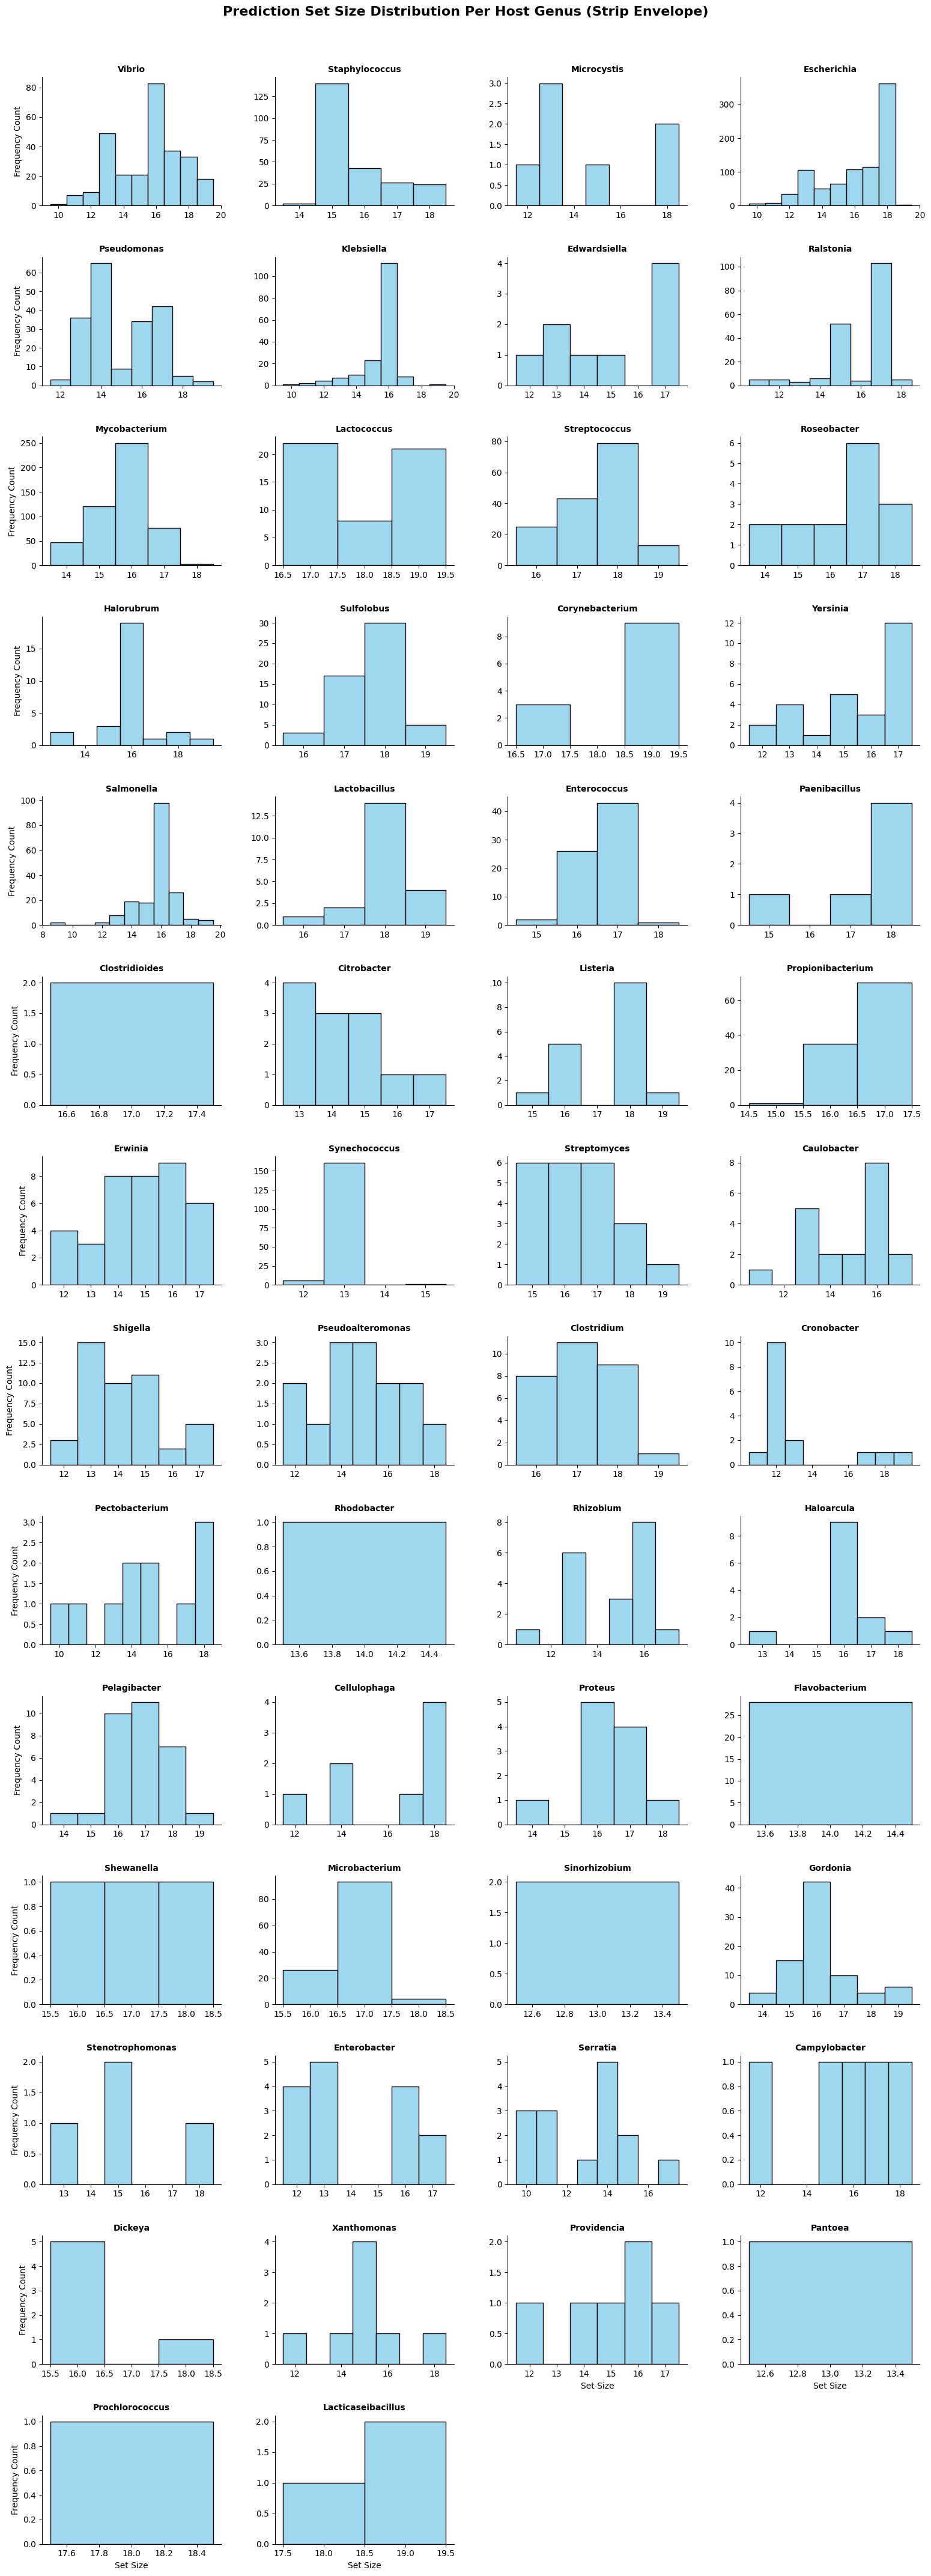

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Gather the set sizes for the strip results
# (You can replace 'strip_results' with 'collapsed_results' or 'radial_results')
host_set_sizes = []
for i, res in enumerate(strip_results):
    host_set_sizes.append({
        "True Host": test_labels[i],
        "Prediction Set Size": len(res["prediction_set"])
    })

df_set_sizes = pd.DataFrame(host_set_sizes)

# 2. Set up a FacetGrid - creating a separate histogram for each host
# 'col_wrap=4' means it will display 4 histogram plots per row
g = sns.FacetGrid(
    df_set_sizes, 
    col="True Host", 
    col_wrap=4, 
    sharex=False, # Allows the X-axis to adjust if some hosts have much larger sets
    sharey=False, # Allows Y-axis to adjust based on the sample size of each host
    height=3, 
    aspect=1.3
)

# 3. Map a discrete histogram (bar-style) onto each grid cell
g.map_dataframe(
    sns.histplot, 
    x="Prediction Set Size", 
    discrete=True, # Forces integer bins (1, 2, 3...) since set sizes are whole numbers
    color="skyblue", 
    edgecolor="black",
    alpha=0.8
)

# 4. Clean up titles and formatting so it looks professional
g.set_titles("{col_name}", fontweight="bold", size=10)
g.set_axis_labels("Set Size", "Frequency Count")

# Adjust spacing so titles and axes do not overlap
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.suptitle("Prediction Set Size Distribution Per Host Genus (Strip Envelope)", y=1.02, fontsize=16, fontweight="bold")

plt.show()

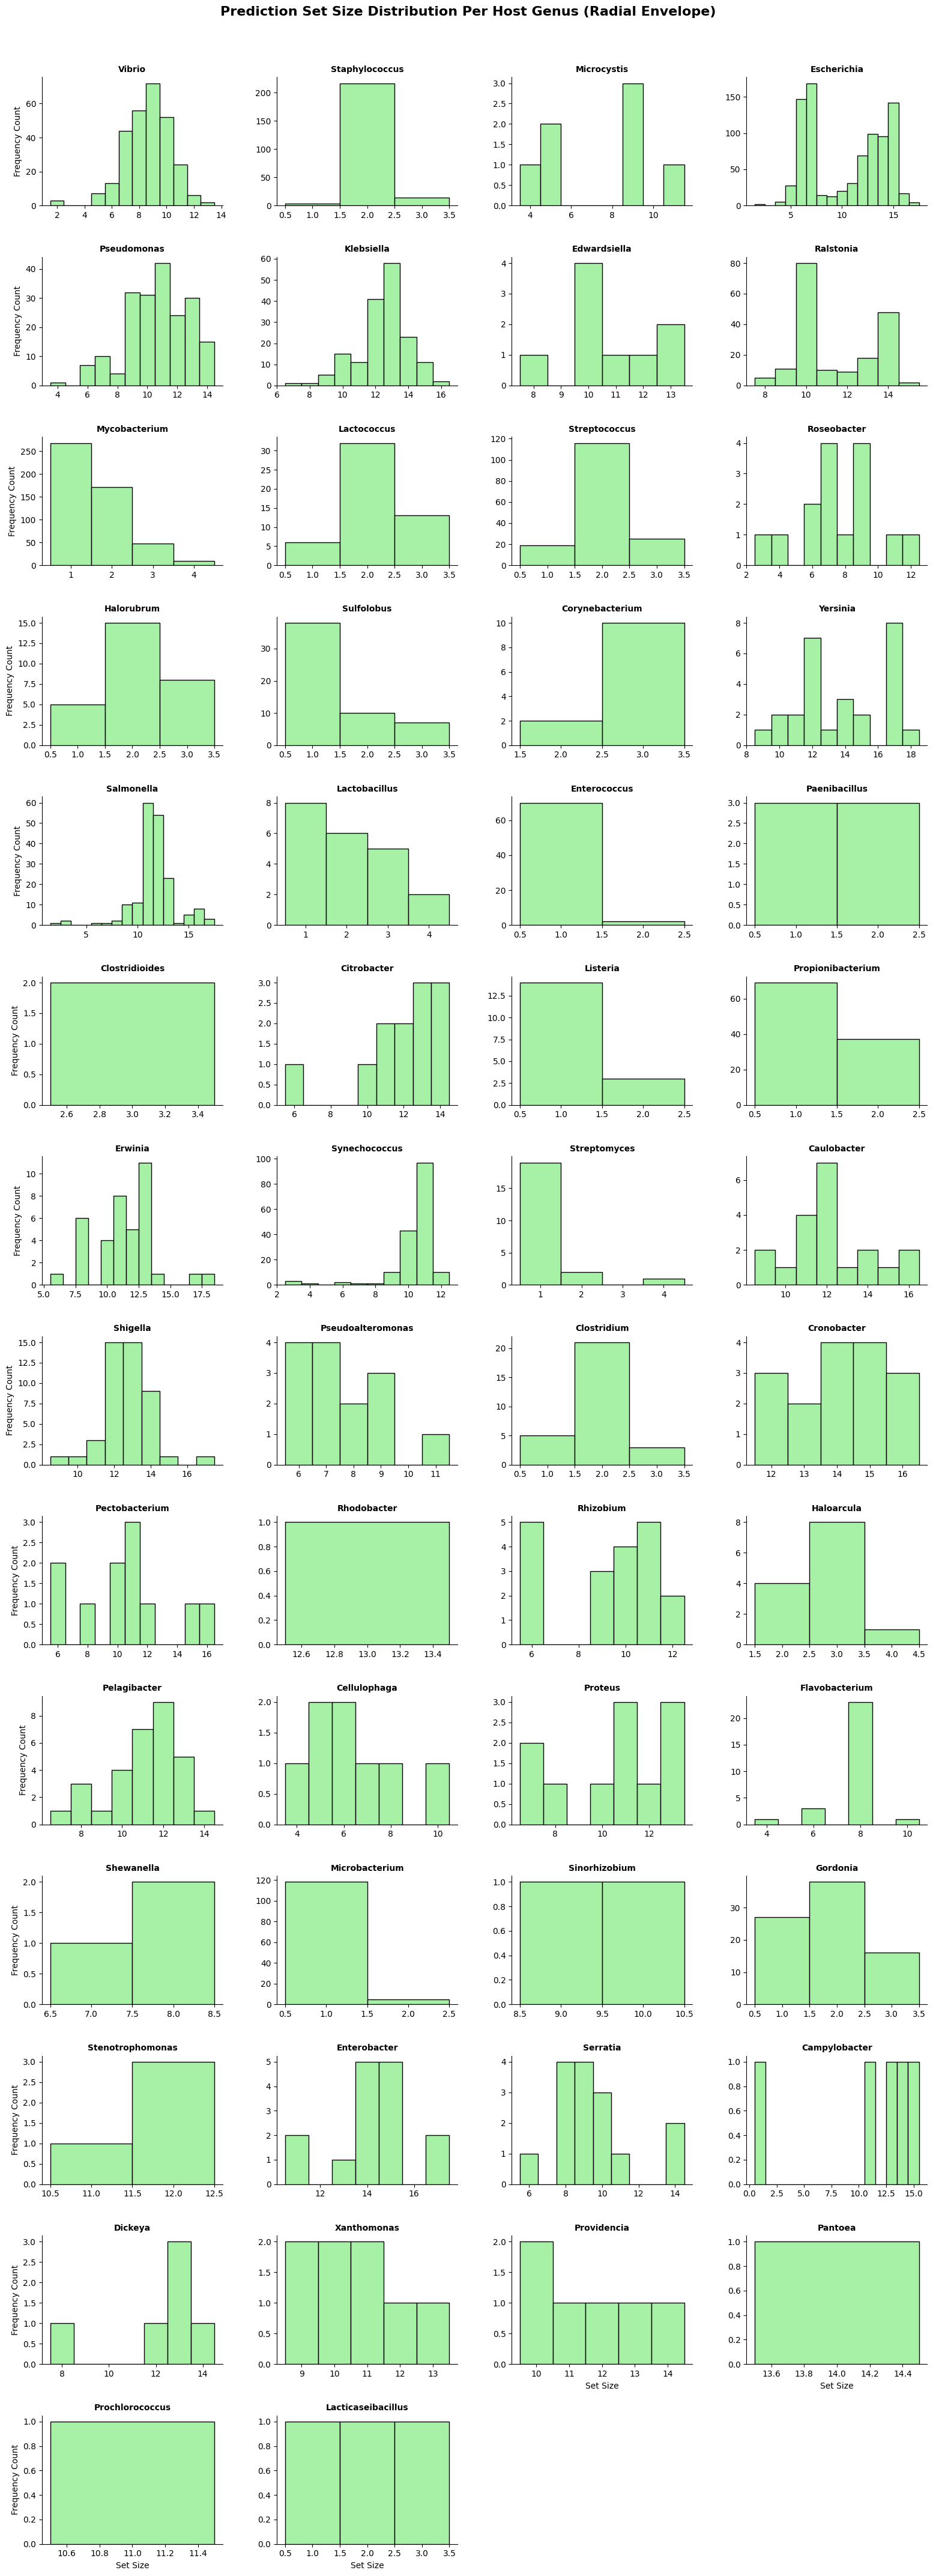

In [29]:
# 1. Gather the set sizes for the strip results
# (You can replace 'strip_results' with 'collapsed_results' or 'radial_results')
host_set_sizes = []
for i, res in enumerate(collapsed_results):
    host_set_sizes.append({
        "True Host": test_labels[i],
        "Prediction Set Size": len(res["prediction_set"])
    })

df_set_sizes = pd.DataFrame(host_set_sizes)

# 2. Set up a FacetGrid - creating a separate histogram for each host
# 'col_wrap=4' means it will display 4 histogram plots per row
g = sns.FacetGrid(
    df_set_sizes, 
    col="True Host", 
    col_wrap=4, 
    sharex=False, # Allows the X-axis to adjust if some hosts have much larger sets
    sharey=False, # Allows Y-axis to adjust based on the sample size of each host
    height=3, 
    aspect=1.3
)

# 3. Map a discrete histogram (bar-style) onto each grid cell
g.map_dataframe(
    sns.histplot, 
    x="Prediction Set Size", 
    discrete=True, # Forces integer bins (1, 2, 3...) since set sizes are whole numbers
    color="lightgreen", 
    edgecolor="black",
    alpha=0.8
)

# 4. Clean up titles and formatting so it looks professional
g.set_titles("{col_name}", fontweight="bold", size=10)
g.set_axis_labels("Set Size", "Frequency Count")

# Adjust spacing so titles and axes do not overlap
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.suptitle("Prediction Set Size Distribution Per Host Genus (Radial Envelope)", y=1.02, fontsize=16, fontweight="bold")

plt.show()

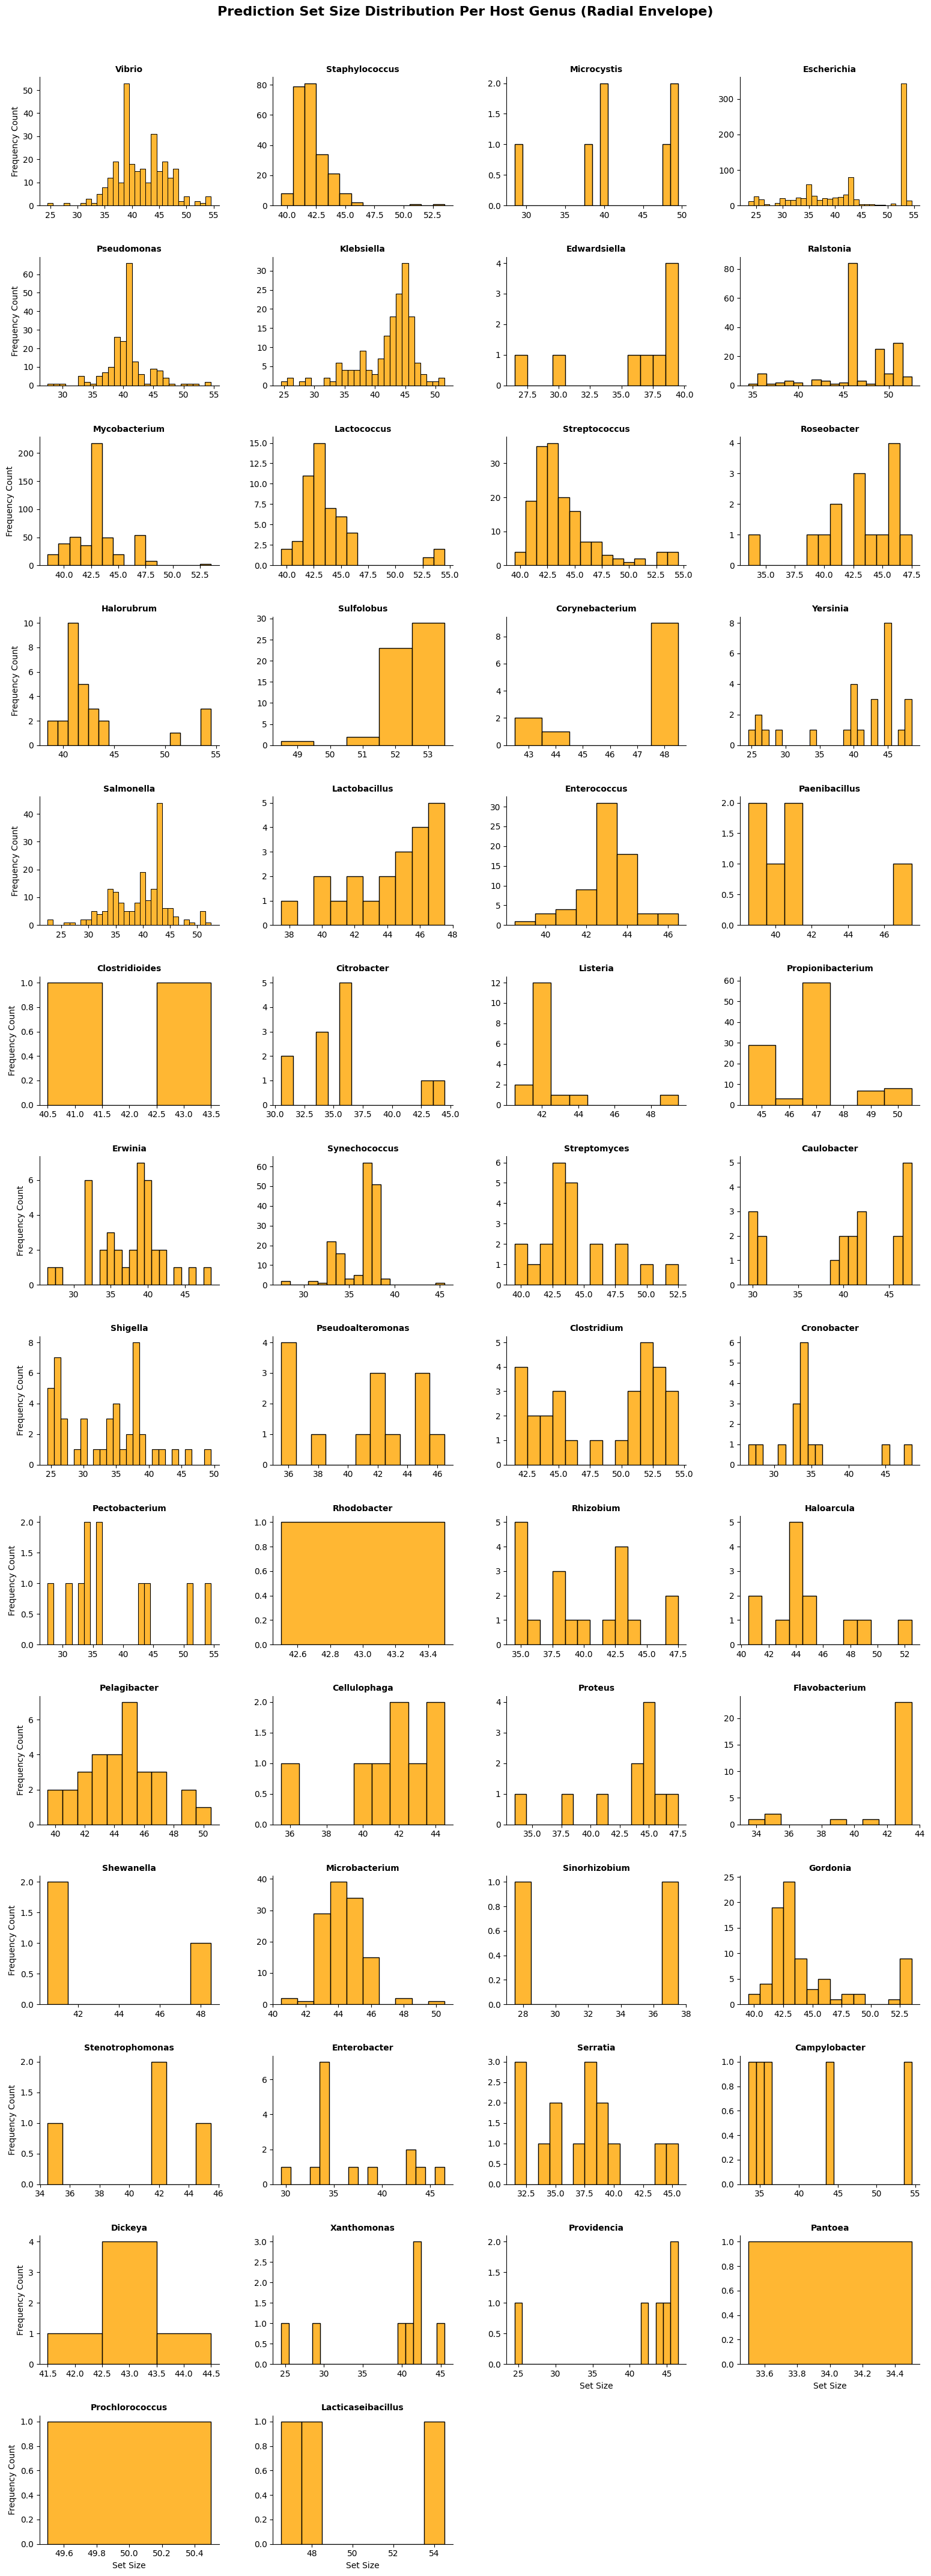

In [30]:
# 1. Gather the set sizes for the strip results
# (You can replace 'strip_results' with 'collapsed_results' or 'radial_results')
host_set_sizes = []
for i, res in enumerate(radial_results):
    host_set_sizes.append({
        "True Host": test_labels[i],
        "Prediction Set Size": len(res["prediction_set"])
    })

df_set_sizes = pd.DataFrame(host_set_sizes)

# 2. Set up a FacetGrid - creating a separate histogram for each host
# 'col_wrap=4' means it will display 4 histogram plots per row
g = sns.FacetGrid(
    df_set_sizes, 
    col="True Host", 
    col_wrap=4, 
    sharex=False, # Allows the X-axis to adjust if some hosts have much larger sets
    sharey=False, # Allows Y-axis to adjust based on the sample size of each host
    height=3, 
    aspect=1.3
)

# 3. Map a discrete histogram (bar-style) onto each grid cell
g.map_dataframe(
    sns.histplot, 
    x="Prediction Set Size", 
    discrete=True, # Forces integer bins (1, 2, 3...) since set sizes are whole numbers
    color="orange", 
    edgecolor="black",
    alpha=0.8
)

# 4. Clean up titles and formatting so it looks professional
g.set_titles("{col_name}", fontweight="bold", size=10)
g.set_axis_labels("Set Size", "Frequency Count")

# Adjust spacing so titles and axes do not overlap
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.suptitle("Prediction Set Size Distribution Per Host Genus (Radial Envelope)", y=1.02, fontsize=16, fontweight="bold")

plt.show()

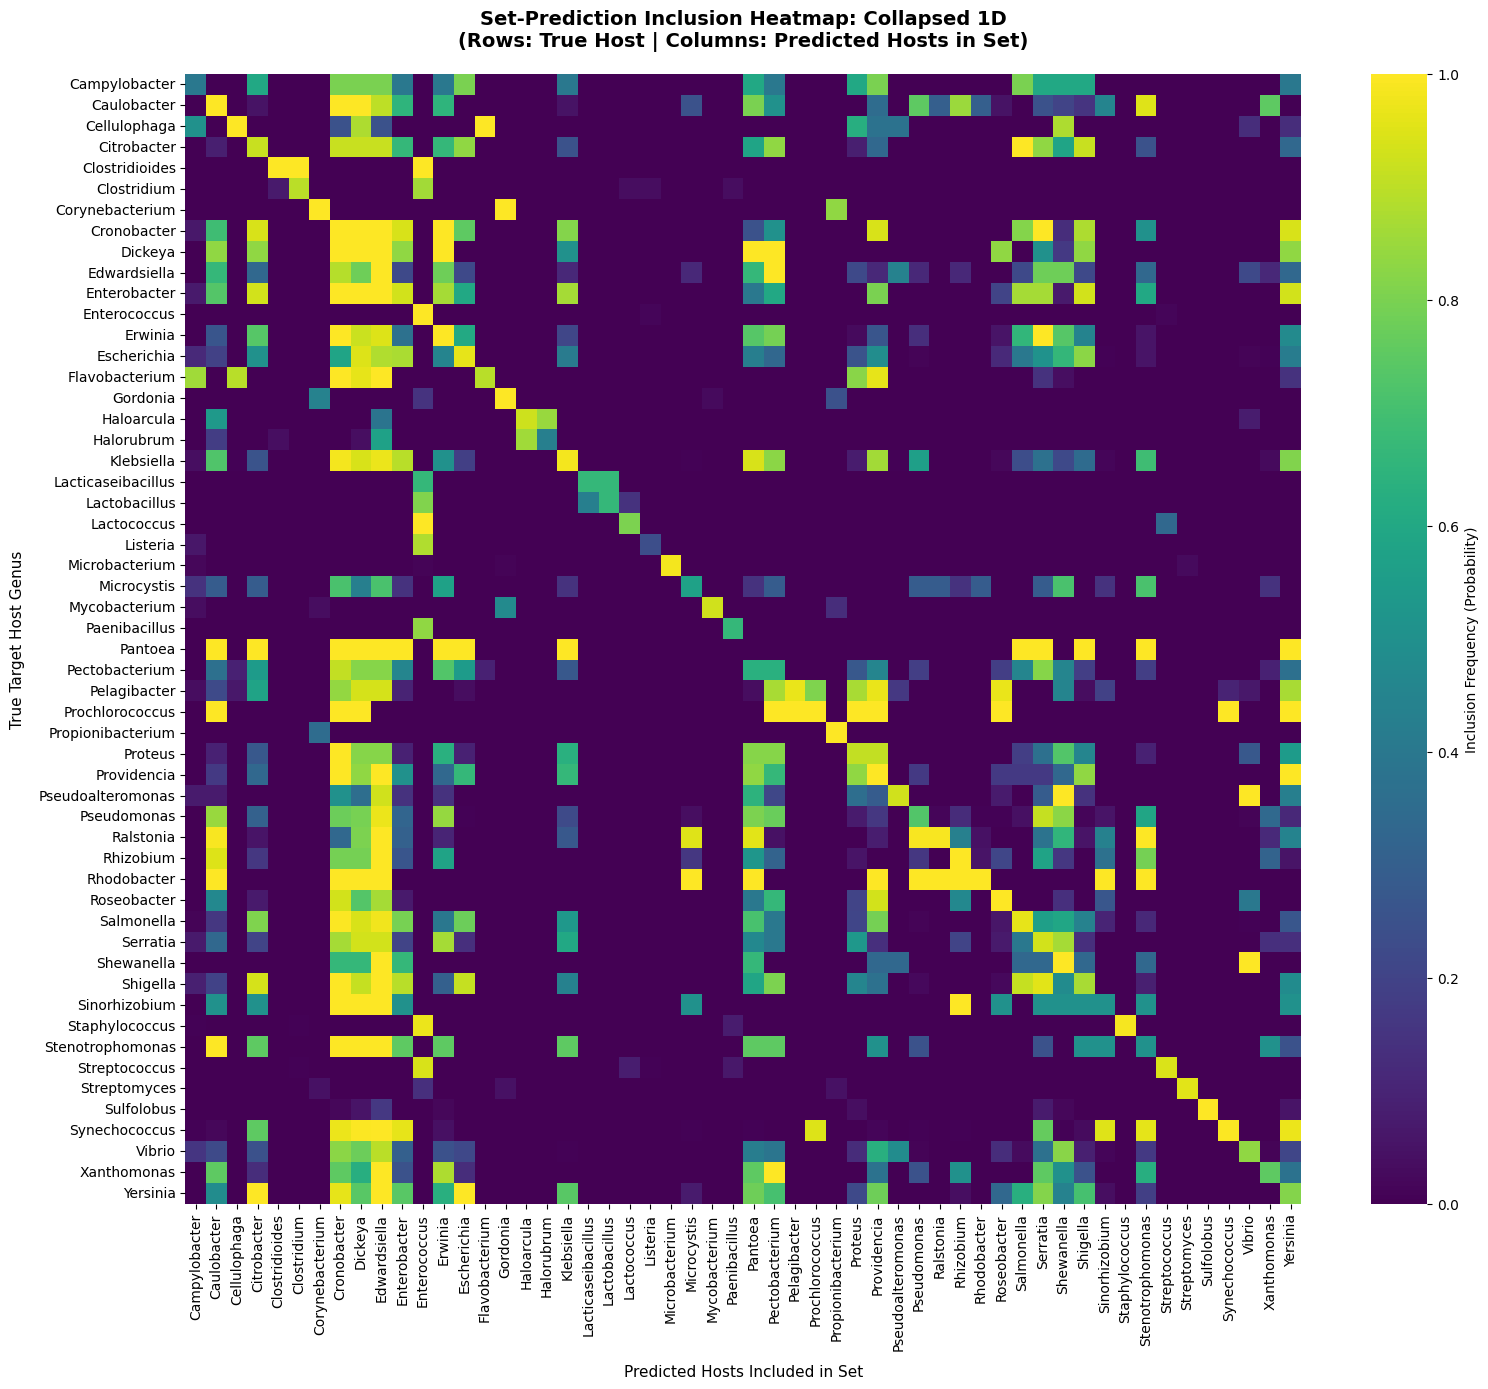

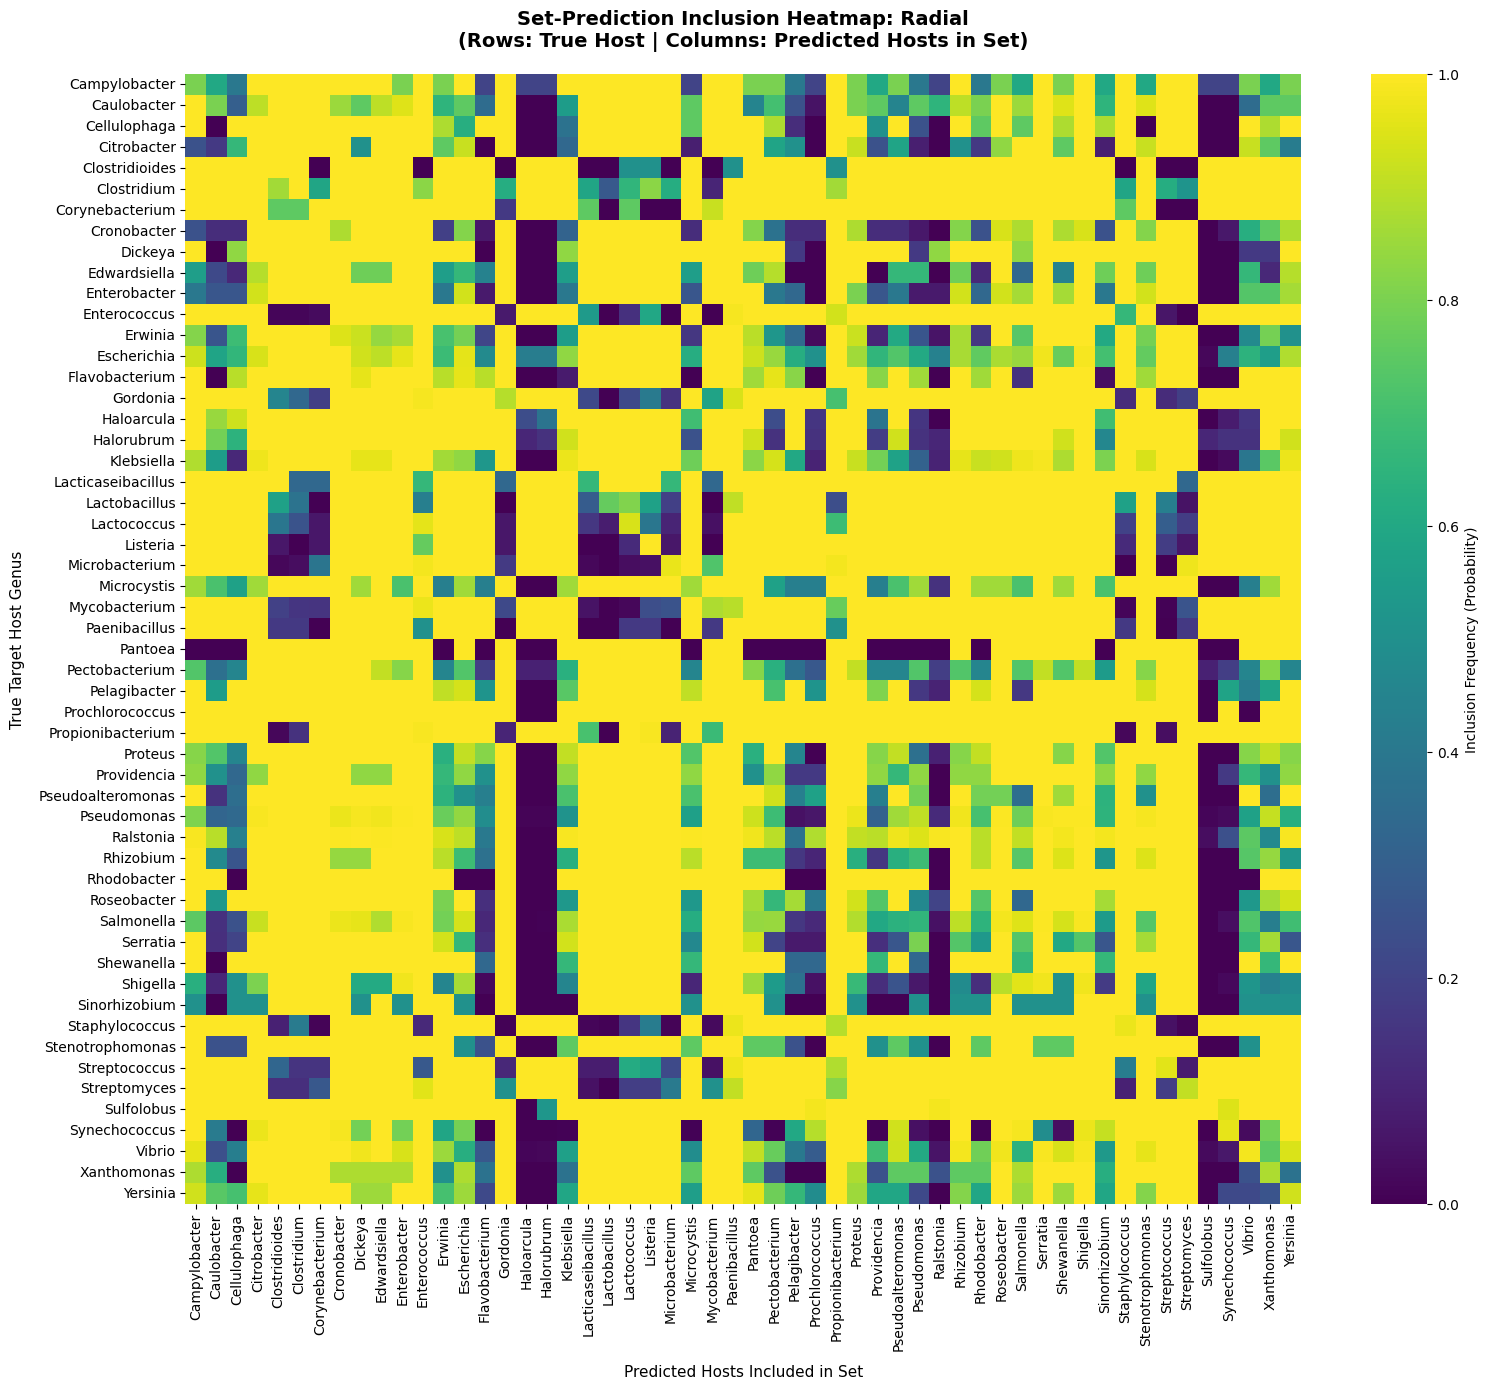

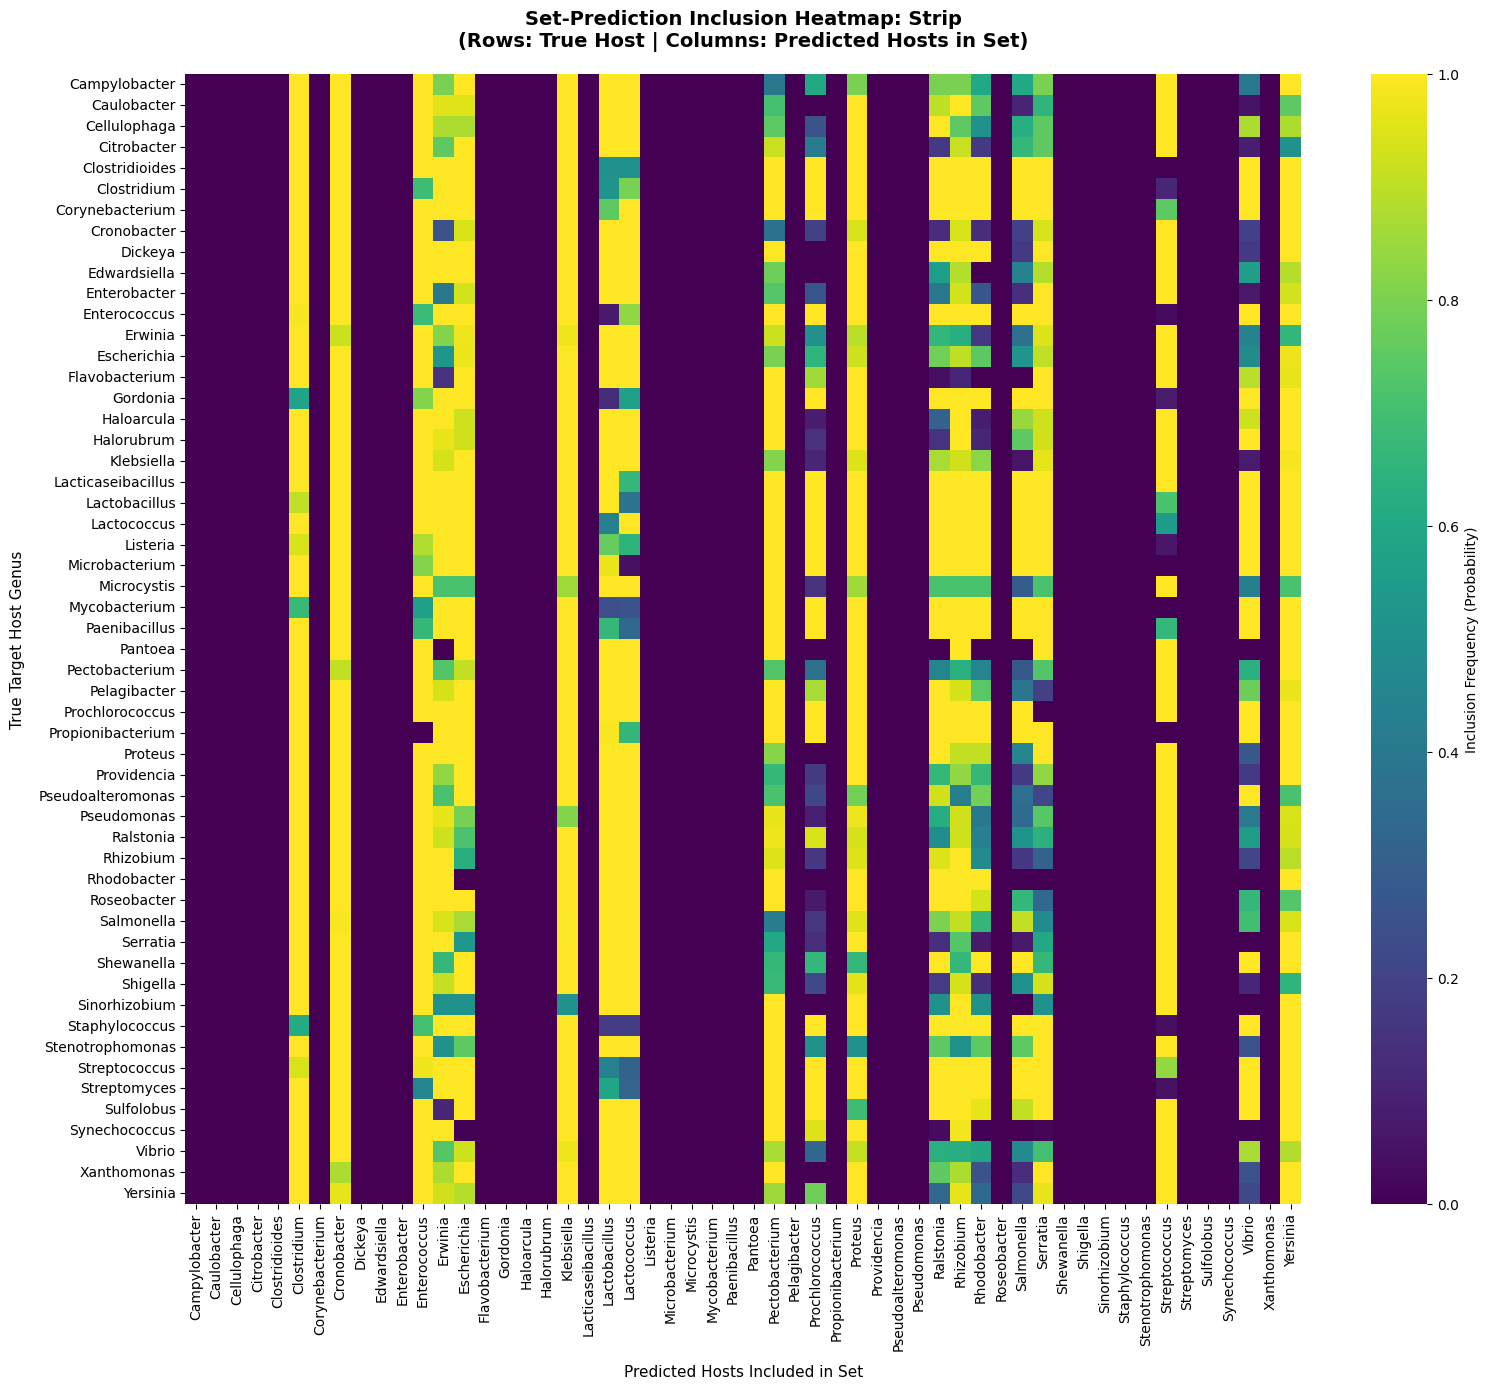

In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Map your evaluation results to their respective names
methods_dict = {
    "Collapsed 1D": collapsed_results,
    "Radial": radial_results,
    "Strip": strip_results
}

# 2. Get a sorted, unique list of all hosts present in the test labels to align rows/columns
unique_hosts = sorted(list(set(test_labels)))
host_to_idx = {host: idx for idx, host in enumerate(unique_hosts)}
n_hosts = len(unique_hosts)

# Loop through each method to create its specific heatmap
for method_name, results_list in methods_dict.items():
    
    # Initialize an empty matrix of shape (n_hosts, n_hosts)
    # Rows = True Hosts, Columns = Predicted Hosts
    matrix = np.zeros((n_hosts, n_hosts))
    row_counts = np.zeros(n_hosts) # To keep track of total phages per true host
    
    # Populate the counts
    for i, res in enumerate(results_list):
        true_host = test_labels[i]
        pred_set = res["prediction_set"] # This is a list/set of predicted hosts
        
        if true_host in host_to_idx:
            row_idx = host_to_idx[true_host]
            row_counts[row_idx] += 1 # Count total phages for this true host
            
            for pred_host in pred_set:
                if pred_host in host_to_idx:
                    col_idx = host_to_idx[pred_host]
                    matrix[row_idx, col_idx] += 1

    # Normalize each row by the number of samples belonging to that true host
    # Using np.where to safely avoid division by zero if a host has no test samples
    normalized_matrix = matrix / np.where(row_counts[:, None] == 0, 1, row_counts[:, None])
    
    # Convert to a DataFrame for clean plotting with labels
    df_heatmap = pd.DataFrame(normalized_matrix, index=unique_hosts, columns=unique_hosts)
    
    # 3. Plot the Heatmap
    # Adjust figure size dynamically based on your 54 hosts so labels are legible
    plt.figure(figsize=(16, 14))
    
    sns.heatmap(
        df_heatmap,
        cmap="viridis",       # Clean color scale (dark blue/purple = 0, yellow = 1)
        vmin=0.0, 
        vmax=1.0,           # Forces color bar boundaries between 0% and 100%
        cbar_kws={'label': 'Inclusion Frequency (Probability)'},
        xticklabels=True, 
        yticklabels=True
    )
    
    plt.title(f"Set-Prediction Inclusion Heatmap: {method_name}\n(Rows: True Host | Columns: Predicted Hosts in Set)", 
              fontsize=14, fontweight="bold", pad=20)
    plt.xlabel("Predicted Hosts Included in Set", fontsize=11, labelpad=10)
    plt.ylabel("True Target Host Genus", fontsize=11, labelpad=10)
    
    plt.tight_layout()
    plt.show()

In [32]:
# ════════════════════════════════════════════════════════════════════
# ENVELOPE VISUALIZATION — sanity check requested by professor
#
# Goal: pick one well-represented gram-positive host, restrict to 2-3
# functions (lysin, endolysin, replication_initiation), build the
# envelope on this low-dimensional sub-space, and PLOT it directly so
# we can visually confirm the envelope shape is sensible.
#
# This assumes train_nc, train_labels, test_raw, test_labels,
# host_col_map, score_cols, all_hosts, alpha are already in memory
# from your main notebook (run this AFTER the main pipeline cells).
# ════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (enables 3d projection)

In [33]:
# ── Step 1: confirm gram-pos / gram-neg hosts never overlap on a function ──
# (Run once, sanity check — not required every time)
import pandas as pd
from pathlib import Path

folder = Path("../Data/random_pc_r_5_da_2_bal_s_0")
neg = pd.read_pickle(folder / "all_preds_gramneg_terminase.pkl")
pos = pd.read_pickle(folder / "all_preds_grampos_terminase.pkl")
neg_hosts = set(c.rsplit("_", 1)[0] for c in neg.columns)
pos_hosts = set(c.rsplit("_", 1)[0] for c in pos.columns)
print("Gramneg/grampos host overlap (should be empty):", neg_hosts & pos_hosts)

Gramneg/grampos host overlap (should be empty): set()


In [34]:
# ── Step 2: pick a well-represented gram-positive host ──────────────────
TARGET_HOST = "Staphylococcus"   # change if a different host is better represented

n_train_target = (train_labels == TARGET_HOST).sum()
print(f"\nTraining phages for {TARGET_HOST}: {n_train_target}")


Training phages for Staphylococcus: 417


In [35]:
# ── Step 3: find the 3 target function columns for this host ────────────
TARGET_FUNCTIONS = ["lysin", "endolysin", "replication_initiation"]

target_cols = []
for func in TARGET_FUNCTIONS:
    col_name = f"{TARGET_HOST}_{func}"
    if col_name in score_cols:
        target_cols.append(col_name)
    else:
        print(f"  WARNING: column '{col_name}' not found in score_cols")

print(f"\nUsing columns: {target_cols}")
target_idx = [score_cols.index(c) for c in target_cols]
K_viz = len(target_idx)
print(f"K_viz = {K_viz} dimensions")


Using columns: ['Staphylococcus_lysin', 'Staphylococcus_endolysin', 'Staphylococcus_replication_initiation']
K_viz = 3 dimensions


In [36]:
# ── Step 4: extract NC sub-vectors for this host, these 3 functions ─────
mask_h = train_labels == TARGET_HOST
train_nc_h = train_nc[mask_h][:, target_idx]     # (n_h, K_viz)
 
mask_h_test = test_labels == TARGET_HOST
test_nc_h_true  = test_raw[mask_h_test][:, target_idx]   # raw scores, true-host test phages
test_nc_h_true  = np.where(np.isnan(test_nc_h_true), np.nan, 1.0 - test_nc_h_true)
 
# Also grab some "other host" test phages for contrast (false hypothesis check)
mask_other_test = test_labels != TARGET_HOST
other_raw = test_raw[mask_other_test][:, target_idx]
other_nc  = np.where(np.isnan(other_raw), np.nan, 1.0 - other_raw)
# Subsample for plot clarity
rng = np.random.default_rng(0)
n_other_show = min(300, other_nc.shape[0])
other_idx_show = rng.choice(other_nc.shape[0], size=n_other_show, replace=False)
other_nc_show = other_nc[other_idx_show]
 
print(f"\nTraining points for {TARGET_HOST} (S1+S2 pool): {train_nc_h.shape}")
print(f"True-host test points: {test_nc_h_true.shape}")
print(f"Other-host test points (sampled): {other_nc_show.shape}")



Training points for Staphylococcus (S1+S2 pool): (417, 3)
True-host test points: (235, 3)
Other-host test points (sampled): (300, 3)


In [37]:
# ── Step 5: split into S1 / S2 and build the THREE envelope types ───────
idx = rng.permutation(len(train_nc_h))
half = len(train_nc_h) // 2
S1 = train_nc_h[idx[:half]]
S2 = train_nc_h[idx[half:]]
labels_S2 = np.array([TARGET_HOST] * len(S2))

# NOTE: these functions (collapsed_build_envelope, radial_build_envelope,
# strip_build_envelope, etc.) must already be defined from your main
# notebook — copy/paste this cell directly below them.

env_collapsed = collapsed_build_envelope(S1, S2, labels_S2, [TARGET_HOST], alpha)
env_radial    = radial_build_envelope(S1, S2, labels_S2, [TARGET_HOST], alpha, M=200)
env_strip     = strip_build_envelope(S1, S2, labels_S2, [TARGET_HOST], alpha, M=10)

print(f"\nCollapsed threshold: {env_collapsed['q_tilde'] * env_collapsed['t_hat']:.4f}")
print(f"Radial t_hat: {env_radial['t_hat']:.4f}")
print(f"Strip t_hat: {env_strip['t_hat']:.4f}")


Collapsed threshold: 0.6119
Radial t_hat: 0.9827
Strip t_hat: 1.0266


Saved envelope_scatter_pairwise.png


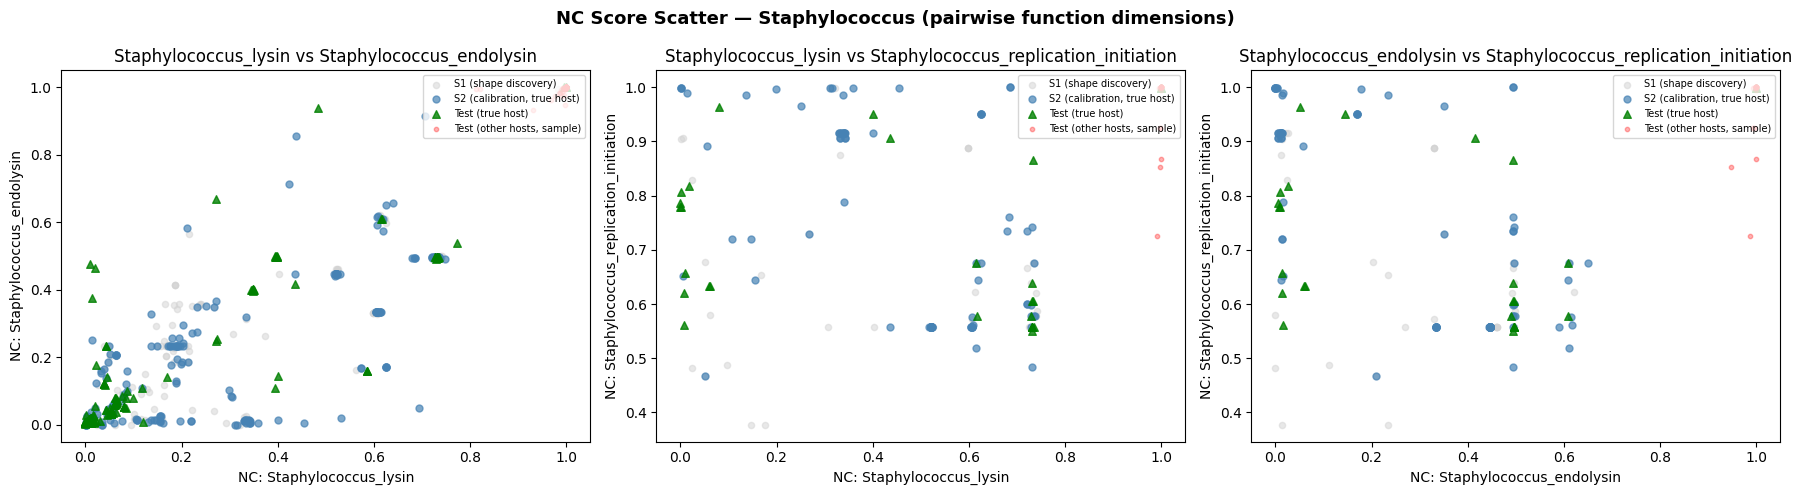

In [38]:
# ════════════════════════════════════════════════════════════════════
# PLOT 1 — 2D pairwise scatter (if K_viz >= 2), all 3 function pairs
# ════════════════════════════════════════════════════════════════════
if K_viz >= 2:
    pairs = [(0, 1), (0, 2), (1, 2)] if K_viz == 3 else [(0, 1)]
    fig, axes = plt.subplots(1, len(pairs), figsize=(6 * len(pairs), 5))
    if len(pairs) == 1:
        axes = [axes]

    for ax, (d1, d2) in zip(axes, pairs):
        ax.scatter(S1[:, d1], S1[:, d2], c="lightgray", s=20, alpha=0.5, label="S1 (shape discovery)")
        ax.scatter(S2[:, d1], S2[:, d2], c="steelblue", s=25, alpha=0.7, label="S2 (calibration, true host)")
        ax.scatter(test_nc_h_true[:, d1], test_nc_h_true[:, d2], c="green", s=30,
                   marker="^", alpha=0.8, label="Test (true host)")
        ax.scatter(other_nc_show[:, d1], other_nc_show[:, d2], c="red", s=10,
                   alpha=0.3, label="Test (other hosts, sample)")

        ax.set_xlabel(f"NC: {target_cols[d1]}")
        ax.set_ylabel(f"NC: {target_cols[d2]}")
        ax.set_title(f"{target_cols[d1]} vs {target_cols[d2]}")
        ax.legend(fontsize=7, loc="upper right")

    plt.suptitle(f"NC Score Scatter — {TARGET_HOST} (pairwise function dimensions)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("envelope_scatter_pairwise.png", dpi=200)
    print("Saved envelope_scatter_pairwise.png")
    plt.show()

Saved envelope_3d_scatter.png


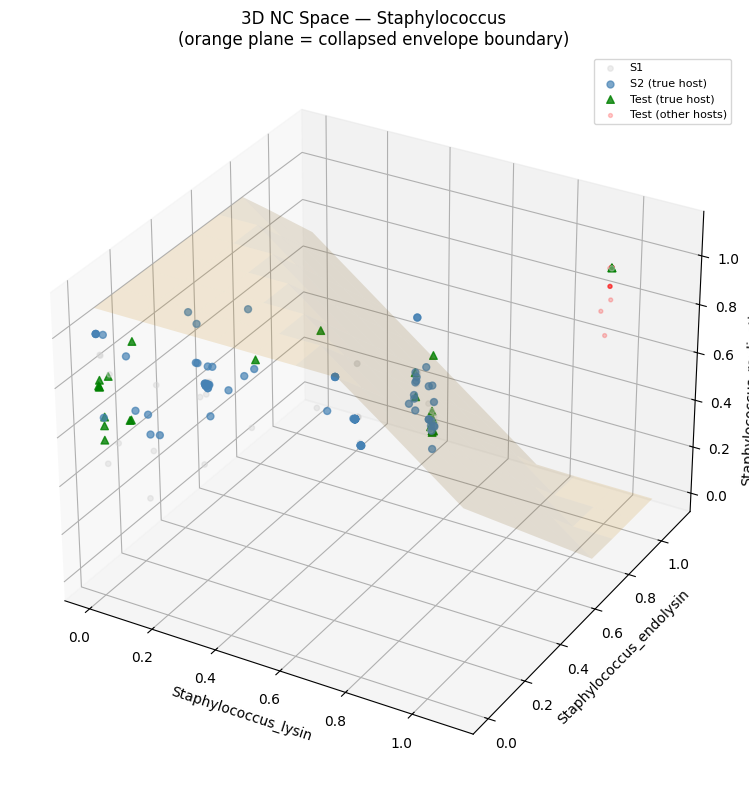

In [39]:
# ════════════════════════════════════════════════════════════════════
# PLOT 2 — 3D scatter with collapsed envelope boundary (single scalar
# threshold == a plane in normalized mean space; shown as a diagonal
# reference surface in the 3 raw dims for intuition)
# ════════════════════════════════════════════════════════════════════
if K_viz == 3:
    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(S1[:, 0], S1[:, 1], S1[:, 2], c="lightgray", s=15, alpha=0.4, label="S1")
    ax.scatter(S2[:, 0], S2[:, 1], S2[:, 2], c="steelblue", s=25, alpha=0.7, label="S2 (true host)")
    ax.scatter(test_nc_h_true[:, 0], test_nc_h_true[:, 1], test_nc_h_true[:, 2],
               c="green", s=30, marker="^", alpha=0.8, label="Test (true host)")
    ax.scatter(other_nc_show[:, 0], other_nc_show[:, 1], other_nc_show[:, 2],
               c="red", s=8, alpha=0.2, label="Test (other hosts)")

    # Collapsed envelope boundary: mean(x,y,z) = threshold  → plane x+y+z = 3*threshold
    threshold = env_collapsed["q_tilde"] * env_collapsed["t_hat"]
    lim = np.nanmax(train_nc_h) * 1.1
    xx, yy = np.meshgrid(np.linspace(0, lim, 10), np.linspace(0, lim, 10))
    zz = 3 * threshold - xx - yy
    zz = np.clip(zz, 0, lim)
    ax.plot_surface(xx, yy, zz, alpha=0.15, color="orange")

    ax.set_xlabel(target_cols[0])
    ax.set_ylabel(target_cols[1])
    ax.set_zlabel(target_cols[2])
    ax.set_title(f"3D NC Space — {TARGET_HOST}\n(orange plane = collapsed envelope boundary)")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig("envelope_3d_scatter.png", dpi=200)
    print("Saved envelope_3d_scatter.png")
    plt.show()

Saved envelope_radial_boundary.png


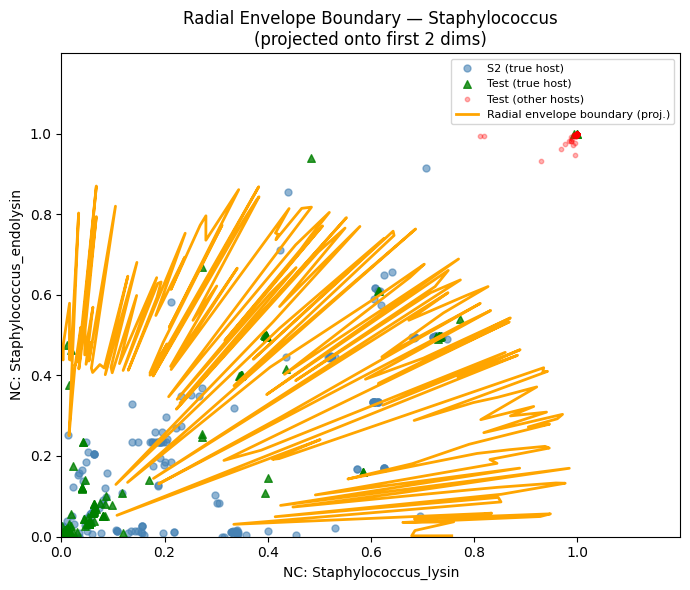

In [40]:
# PLOT 3 — Radial envelope boundary overlay (2D projection, first 2 dims)
# This shows the actual radial boundary points U * q_tilde * t_hat
# ════════════════════════════════════════════════════════════════════
if K_viz >= 2:
    fig, ax = plt.subplots(figsize=(7, 6))

    ax.scatter(S2[:, 0], S2[:, 1], c="steelblue", s=25, alpha=0.6, label="S2 (true host)")
    ax.scatter(test_nc_h_true[:, 0], test_nc_h_true[:, 1], c="green", s=30,
               marker="^", alpha=0.8, label="Test (true host)")
    ax.scatter(other_nc_show[:, 0], other_nc_show[:, 1], c="red", s=10,
               alpha=0.3, label="Test (other hosts)")

    # Radial boundary points projected onto dims 0,1
    U, q_tilde, t_hat = env_radial["U"], env_radial["q_tilde"], env_radial["t_hat"]
    boundary = U * (q_tilde * t_hat)[:, None]
    # Sort by angle in the (0,1) plane for a clean boundary line
    angles = np.arctan2(boundary[:, 1], boundary[:, 0])
    order = np.argsort(angles)
    ax.plot(boundary[order, 0], boundary[order, 1], c="orange", lw=2,
            label="Radial envelope boundary (proj.)")

    ax.set_xlabel(f"NC: {target_cols[0]}")
    ax.set_ylabel(f"NC: {target_cols[1]}")
    ax.set_title(f"Radial Envelope Boundary — {TARGET_HOST}\n(projected onto first 2 dims)")
    ax.legend(fontsize=8)
    ax.set_xlim(0, np.nanmax(train_nc_h[:, 0]) * 1.2)
    ax.set_ylim(0, np.nanmax(train_nc_h[:, 1]) * 1.2)
    plt.tight_layout()
    plt.savefig("envelope_radial_boundary.png", dpi=200)
    print("Saved envelope_radial_boundary.png")
    plt.show()

In [41]:
# Check 1: true-host test points should mostly be INSIDE
in_true_collapsed = collapsed_is_in_region(test_nc_h_true, env_collapsed)
print(f"\nTrue-host test phages inside COLLAPSED envelope: "
      f"{in_true_collapsed.sum()}/{len(in_true_collapsed)} "
      f"({in_true_collapsed.mean()*100:.1f}%)  (target >= {(1-alpha)*100:.0f}%)")

in_true_radial = radial_is_in_region(test_nc_h_true, env_radial)
print(f"True-host test phages inside RADIAL envelope:    "
      f"{in_true_radial.sum()}/{len(in_true_radial)} "
      f"({in_true_radial.mean()*100:.1f}%)")

in_true_strip = strip_is_in_region(test_nc_h_true, env_strip)
print(f"True-host test phages inside STRIP envelope:     "
      f"{in_true_strip.sum()}/{len(in_true_strip)} "
      f"({in_true_strip.mean()*100:.1f}%)")

# Check 2: other-host test points should mostly be OUTSIDE (low false-positive rate)
in_other_collapsed = collapsed_is_in_region(other_nc_show, env_collapsed)
print(f"\nOther-host test phages inside COLLAPSED envelope (false positives): "
      f"{in_other_collapsed.mean()*100:.1f}%  (lower is better — tighter envelope)")

in_other_radial = radial_is_in_region(other_nc_show, env_radial)
print(f"Other-host test phages inside RADIAL envelope (false positives):    "
      f"{in_other_radial.mean()*100:.1f}%")

in_other_strip = strip_is_in_region(other_nc_show, env_strip)
print(f"Other-host test phages inside STRIP envelope (false positives):     "
      f"{in_other_strip.mean()*100:.1f}%")


True-host test phages inside COLLAPSED envelope: 227/235 (96.6%)  (target >= 90%)
True-host test phages inside RADIAL envelope:    225/235 (95.7%)
True-host test phages inside STRIP envelope:     229/235 (97.4%)

Other-host test phages inside COLLAPSED envelope (false positives): 0.0%  (lower is better — tighter envelope)
Other-host test phages inside RADIAL envelope (false positives):    69.0%
Other-host test phages inside STRIP envelope (false positives):     69.3%


---

In [42]:
# ════════════════════════════════════════════════════════════════════
# STEP 1 — Explicitly separate gram-positive and gram-negative hosts
#
# Run this AFTER your existing data-loading cells (after score_cols,
# all_hosts, host_col_map, train_df, test_df, phage_df are built).
# ════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd

# ── 1. Confirm host_type is available per phage (already in phage_df) ──
print("host_type values in phage_df:")
print(phage_df["host_type"].value_counts())

# ── 2. Build an explicit map: host genus -> gram type ───────────────────
# A host genus's gram type should be CONSISTENT across all phages that
# have that host as their true label. Verify this assumption first.
host_to_gramtype = {}
inconsistent_hosts = []

for h in all_hosts:
    types_for_host = phage_df.loc[phage_df["host"] == h, "host_type"].unique()
    types_for_host = [t for t in types_for_host if pd.notna(t)]
    if len(types_for_host) == 0:
        continue  # no phages with this true host in our data
    if len(types_for_host) > 1:
        inconsistent_hosts.append((h, types_for_host))
    host_to_gramtype[h] = types_for_host[0]

print(f"\nHosts with a single, consistent gram type: {len(host_to_gramtype)}")
if inconsistent_hosts:
    print(f"WARNING — hosts with inconsistent gram type across phages:")
    for h, types in inconsistent_hosts:
        print(f"  {h}: {types}")
else:
    print("No inconsistencies found — every host genus maps to exactly one gram type.")

# ── 3. Cross-check against the PREDICTION FILE source (not just metadata) ──
# This verifies that host_col_map[h] columns actually all came from the
# correct gramtype's prediction files, not just that metadata SAYS so.
from pathlib import Path

folder_s0 = Path("../Data/random_pc_r_5_da_2_bal_s_0")
gramneg_files = list(folder_s0.glob("all_preds_gramneg_*.pkl"))
grampos_files = list(folder_s0.glob("all_preds_grampos_*.pkl"))

gramneg_hosts_seen = set()
for f in gramneg_files:
    df = pd.read_pickle(f)
    gramneg_hosts_seen.update(c.rsplit("_", 1)[0] for c in df.columns)

grampos_hosts_seen = set()
for f in grampos_files:
    df = pd.read_pickle(f)
    grampos_hosts_seen.update(c.rsplit("_", 1)[0] for c in df.columns)

print(f"\nHosts seen ONLY in gramneg files: {len(gramneg_hosts_seen)}")
print(f"Hosts seen ONLY in grampos files: {len(grampos_hosts_seen)}")
overlap = gramneg_hosts_seen & grampos_hosts_seen
print(f"Hosts appearing in BOTH file types (should be empty): {overlap}")

# ── 4. Build the two explicit host groups for downstream use ────────────
gram_pos_hosts = sorted([h for h in all_hosts if host_to_gramtype.get(h) == "gram-pos"])
gram_neg_hosts = sorted([h for h in all_hosts if host_to_gramtype.get(h) == "gram-neg"])

print(f"\nGram-positive hosts ({len(gram_pos_hosts)}): {gram_pos_hosts}")
print(f"\nGram-negative hosts ({len(gram_neg_hosts)}): {gram_neg_hosts}")

# Sanity: do these match the prediction-file-derived sets?
print(f"\nMismatch check (metadata-derived vs prediction-file-derived):")
print(f"  gram_pos_hosts vs grampos_hosts_seen: {set(gram_pos_hosts) - grampos_hosts_seen}")
print(f"  gram_neg_hosts vs gramneg_hosts_seen: {set(gram_neg_hosts) - gramneg_hosts_seen}")

host_type values in phage_df:
host_type
gram-neg    9124
gram-pos    6514
Name: count, dtype: int64

Hosts with a single, consistent gram type: 54
No inconsistencies found — every host genus maps to exactly one gram type.

Hosts seen ONLY in gramneg files: 400
Hosts seen ONLY in grampos files: 161
Hosts appearing in BOTH file types (should be empty): set()

Gram-positive hosts (16): ['Clostridioides', 'Clostridium', 'Corynebacterium', 'Enterococcus', 'Gordonia', 'Lacticaseibacillus', 'Lactobacillus', 'Lactococcus', 'Listeria', 'Microbacterium', 'Mycobacterium', 'Paenibacillus', 'Propionibacterium', 'Staphylococcus', 'Streptococcus', 'Streptomyces']

Gram-negative hosts (38): ['Campylobacter', 'Caulobacter', 'Cellulophaga', 'Citrobacter', 'Cronobacter', 'Dickeya', 'Edwardsiella', 'Enterobacter', 'Erwinia', 'Escherichia', 'Flavobacterium', 'Haloarcula', 'Halorubrum', 'Klebsiella', 'Microcystis', 'Pantoea', 'Pectobacterium', 'Pelagibacter', 'Prochlorococcus', 'Proteus', 'Providencia', 'Ps

In [ ]:
# ════════════════════════════════════════════════════════════════════
# STEP 2 — Run host classification SEPARATELY within each gram group
#
# Uses gram_pos_hosts / gram_neg_hosts from STEP 1 to shrink the candidate
# host list BEFORE building/evaluating envelopes, instead of pooling all
# ~54 hosts together. Compare the numbers below against the pooled
# baseline already computed above (collapsed_metrics / radial_metrics /
# strip_metrics) to see whether this actually helps.
# ════════════════════════════════════════════════════════════════════

def run_host_pipeline_for_group(group_hosts, method):
    envs = build_per_host_envelopes(
        train_nc, train_labels, group_hosts, score_cols, host_col_map, alpha,
        method=method, seed=42
    )
    mask_test_group = np.isin(test_labels, group_hosts)
    results = predict_host(test_raw[mask_test_group], envs, group_hosts)
    metrics = evaluate_multiclass(results, test_labels[mask_test_group], group_hosts, alpha)
    return results, metrics

gram_group_metrics = {}
for method in ["collapsed", "radial", "strip"]:
    for group_hosts, group_name in [(gram_pos_hosts, "GRAM-POS"), (gram_neg_hosts, "GRAM-NEG")]:
        _, m = run_host_pipeline_for_group(group_hosts, method)
        gram_group_metrics[(method, group_name)] = m

print("=== HOST CLASSIFICATION, RUN SEPARATELY PER GRAM GROUP ===")
print("(compare avg_set_size / min_host_coverage here against the pooled")
print(" all-54-host results above)\n")

rows = []
for method in ["collapsed", "radial", "strip"]:
    for group_hosts, group_name in [(gram_pos_hosts, "GRAM-POS"), (gram_neg_hosts, "GRAM-NEG")]:
        m = gram_group_metrics[(method, group_name)]
        rows.append({
            "Method":         method,
            "Group":          group_name,
            "n_hosts":        len(group_hosts),
            "Coverage":       f"{m['coverage']:.3f}",
            "Avg set size":   f"{m['avg_set_size']:.2f}",
            "Singleton rate": f"{m['singleton_rate']:.3f}",
            "Forced rate":    f"{m['forced_rate']:.3f}",
            "Min host cov.":  f"{m['min_host_coverage']:.3f}" if m["min_host_coverage"] else "N/A",
        })
print(pd.DataFrame(rows).to_string(index=False))

print("\nNOTE: this uses the TRUE host_type (known from metadata) to restrict")
print("the candidate host list for each test phage -- it isolates 'does shrinking")
print("the candidate pool help the envelope methods', on its own. It is NOT yet a")
print("full two-stage predictor: that would PREDICT gram type for a new, unlabeled")
print("phage using the Gram_Classification notebook's envelope, then restrict")
print("candidates by the predicted SET (not the true label). If you build that")
print("version, split the alpha budget across both stages (e.g. alpha/2 each) to")
print("keep the overall (1-alpha) coverage guarantee valid -- chaining two")
print("(1-alpha) procedures does not automatically give (1-alpha) overall.")

 DATA AVAILABILITY CHECK

Staphylococcus:
  Training phages : 417
  Test phages     : 235
  Column 'Staphylococcus_lysin': EXISTS
  Column 'Staphylococcus_tail_appendage': EXISTS

Clostridium:
  Training phages : 90
  Test phages     : 29
  Column 'Clostridium_lysin': EXISTS
  Column 'Clostridium_tail_appendage': EXISTS

Staphylococcus: built envelopes on 417 training phages, 235 test phages
  Collapsed threshold: 0.5909
  Radial t_hat: 0.9880
  Strip t_hat: 1.0000

Clostridium: built envelopes on 90 training phages, 29 test phages
  Collapsed threshold: 0.8554
  Radial t_hat: 1.0131
  Strip t_hat: 1.0155

Saved envelope_staph_vs_clostridium.png


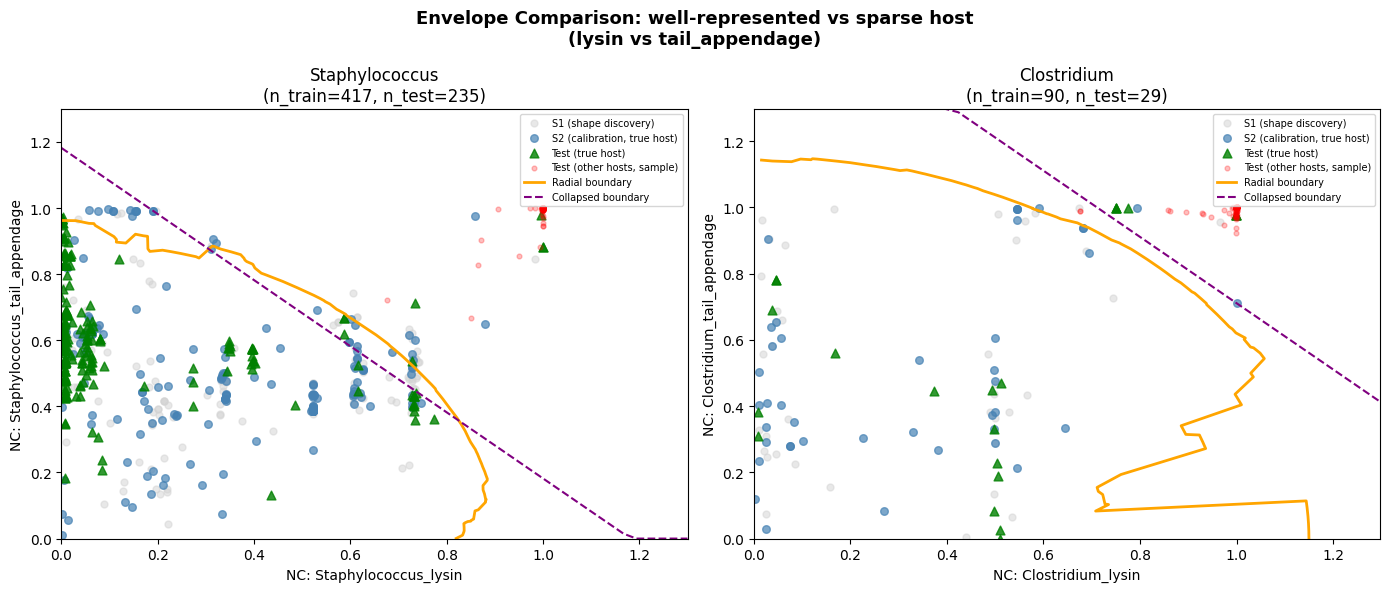


 NUMERIC COMPARISON

--- Staphylococcus (n_train=417) ---
  Collapsed : true-host inside =  96.6%  |  other-host inside (false pos) =   0.0%
  Radial    : true-host inside =  94.5%  |  other-host inside (false pos) =  67.7%
  Strip     : true-host inside =  98.3%  |  other-host inside (false pos) =  75.7%

--- Clostridium (n_train=90) ---
  Collapsed : true-host inside =  55.2%  |  other-host inside (false pos) =   0.7%
  Radial    : true-host inside =  75.9%  |  other-host inside (false pos) =  72.7%
  Strip     : true-host inside =  75.9%  |  other-host inside (false pos) =  73.3%

Interpretation for the meeting:
  If Clostridium's envelope is much looser (high false-positive rate)
  or much more erratic in shape than Staphylococcus's, this directly
  demonstrates the data-scarcity problem per-host envelopes have —
  exactly the kind of bug/limitation check this visualization is for.


In [43]:
# ════════════════════════════════════════════════════════════════════
# 2D ENVELOPE VISUALIZATION — Staphylococcus (well-represented) vs
# Clostridium (sparse) using lysin + tail_appendage
#
# Run this AFTER your main host-classification pipeline cells, i.e.
# after train_nc, test_raw, train_labels, test_labels, score_cols,
# host_col_map, all_hosts, alpha, and the envelope-building functions
# (collapsed_build_envelope, radial_build_envelope, strip_build_envelope,
#  collapsed_is_in_region, radial_is_in_region, strip_is_in_region)
# are already defined / computed.
# ════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt

TARGET_FUNCTIONS = ["lysin", "tail_appendage"]
HOSTS_TO_COMPARE = ["Staphylococcus", "Clostridium"]

# ── Step 1: check data availability for both hosts ──────────────────────
print("=" * 60)
print(" DATA AVAILABILITY CHECK")
print("=" * 60)
for h in HOSTS_TO_COMPARE:
    n_train = (train_labels == h).sum()
    n_test  = (test_labels == h).sum()
    print(f"\n{h}:")
    print(f"  Training phages : {n_train}")
    print(f"  Test phages     : {n_test}")
    for func in TARGET_FUNCTIONS:
        col_name = f"{h}_{func}"
        exists = col_name in score_cols
        print(f"  Column '{col_name}': {'EXISTS' if exists else 'MISSING'}")

# ── Step 2: build envelopes for both hosts on these 2 dimensions ────────
rng = np.random.default_rng(42)
results_by_host = {}

for h in HOSTS_TO_COMPARE:
    target_cols = [f"{h}_{func}" for func in TARGET_FUNCTIONS]
    missing = [c for c in target_cols if c not in score_cols]
    if missing:
        print(f"\nSkipping {h}: missing columns {missing}")
        continue

    target_idx = [score_cols.index(c) for c in target_cols]

    mask_h = train_labels == h
    n_h = mask_h.sum()
    if n_h < 6:
        print(f"\nSkipping {h}: only {n_h} training phages (need >= 6)")
        continue

    train_nc_h = train_nc[mask_h][:, target_idx]

    idx = rng.permutation(n_h)
    half = n_h // 2
    S1 = train_nc_h[idx[:half]]
    S2 = train_nc_h[idx[half:]]
    labels_S2 = np.array([h] * len(S2))

    env_c = collapsed_build_envelope(S1, S2, labels_S2, [h], alpha)
    env_r = radial_build_envelope(S1, S2, labels_S2, [h], alpha, M=200)
    env_s = strip_build_envelope(S1, S2, labels_S2, [h], alpha, M=10)

    mask_h_test = test_labels == h
    test_raw_h = test_raw[mask_h_test][:, target_idx]
    test_nc_h_true = np.where(np.isnan(test_raw_h), np.nan, 1.0 - test_raw_h)

    mask_other_test = test_labels != h
    other_raw = test_raw[mask_other_test][:, target_idx]
    other_nc = np.where(np.isnan(other_raw), np.nan, 1.0 - other_raw)
    n_show = min(300, other_nc.shape[0])
    show_idx = rng.choice(other_nc.shape[0], size=n_show, replace=False)
    other_nc_show = other_nc[show_idx]

    results_by_host[h] = {
        "S1": S1, "S2": S2,
        "test_true": test_nc_h_true,
        "other": other_nc_show,
        "env_c": env_c, "env_r": env_r, "env_s": env_s,
        "target_cols": target_cols,
        "n_train": n_h,
        "n_test": mask_h_test.sum(),
    }

    print(f"\n{h}: built envelopes on {n_h} training phages, "
          f"{mask_h_test.sum()} test phages")
    print(f"  Collapsed threshold: {env_c['q_tilde']*env_c['t_hat']:.4f}")
    print(f"  Radial t_hat: {env_r['t_hat']:.4f}")
    print(f"  Strip t_hat: {env_s['t_hat']:.4f}")

# ── Step 3: side-by-side 2D scatter plots, one column per host ──────────
n_hosts_plotted = len(results_by_host)
if n_hosts_plotted > 0:
    fig, axes = plt.subplots(1, n_hosts_plotted, figsize=(7 * n_hosts_plotted, 6))
    if n_hosts_plotted == 1:
        axes = [axes]

    for ax, (h, data) in zip(axes, results_by_host.items()):
        S1, S2 = data["S1"], data["S2"]
        test_true, other = data["test_true"], data["other"]
        cols = data["target_cols"]

        ax.scatter(S1[:, 0], S1[:, 1], c="lightgray", s=25, alpha=0.5, label="S1 (shape discovery)")
        ax.scatter(S2[:, 0], S2[:, 1], c="steelblue", s=30, alpha=0.7, label="S2 (calibration, true host)")
        ax.scatter(test_true[:, 0], test_true[:, 1], c="green", s=40,
                   marker="^", alpha=0.8, label="Test (true host)")
        ax.scatter(other[:, 0], other[:, 1], c="red", s=12, alpha=0.25, label="Test (other hosts, sample)")

        # Overlay radial boundary
        env_r = data["env_r"]
        U, q_tilde, t_hat = env_r["U"], env_r["q_tilde"], env_r["t_hat"]
        boundary = U * (q_tilde * t_hat)[:, None]
        angles = np.arctan2(boundary[:, 1], boundary[:, 0])
        order = np.argsort(angles)
        ax.plot(boundary[order, 0], boundary[order, 1], c="orange", lw=2, label="Radial boundary")

        # Overlay collapsed boundary (line: x + y = 2*threshold)
        threshold = data["env_c"]["q_tilde"] * data["env_c"]["t_hat"]
        lim = np.nanmax(S1) * 1.3 if np.nanmax(S1) > 0 else 1.0
        xs = np.linspace(0, lim, 50)
        ys = 2 * threshold - xs
        ax.plot(xs, np.clip(ys, 0, lim), c="purple", lw=1.5, ls="--", label="Collapsed boundary")

        # Overlay strip boundary (staircase: per-bin limit on dim1, binned on dim0)
        env_s = data["env_s"]
        bin_edges_s, limits_s, t_hat_s = env_s["bin_edges"], env_s["limits"], env_s["t_hat"]
        M_s = bin_edges_s.shape[1] - 1
        xs_stair, ys_stair = [], []
        for m in range(M_s):
            lo, hi = bin_edges_s[0, m], bin_edges_s[0, m + 1]
            y_lim = limits_s[0, 1, m] * t_hat_s
            xs_stair += [lo, hi]
            ys_stair += [y_lim, y_lim]
        ax.plot(xs_stair, ys_stair, c="teal", lw=1.5, ls="-.", label="Strip boundary")

        ax.set_xlabel(f"NC: {cols[0]}")
        ax.set_ylabel(f"NC: {cols[1]}")
        ax.set_title(f"{h}\n(n_train={data['n_train']}, n_test={data['n_test']})")
        ax.legend(fontsize=7, loc="upper right")
        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)

    plt.suptitle(f"Envelope Comparison: well-represented vs sparse host\n"
                 f"({TARGET_FUNCTIONS[0]} vs {TARGET_FUNCTIONS[1]})",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("envelope_staph_vs_clostridium.png", dpi=200)
    print("\nSaved envelope_staph_vs_clostridium.png")
    plt.show()

# ── Step 4: numeric comparison — does envelope quality degrade with less data? ──
print("\n" + "=" * 60)
print(" NUMERIC COMPARISON")
print("=" * 60)

for h, data in results_by_host.items():
    print(f"\n--- {h} (n_train={data['n_train']}) ---")
    for method_name, env, is_in_region_fn in [
        ("Collapsed", data["env_c"], collapsed_is_in_region),
        ("Radial",    data["env_r"], radial_is_in_region),
        ("Strip",     data["env_s"], strip_is_in_region),
    ]:
        in_true  = is_in_region_fn(data["test_true"], env)
        in_other = is_in_region_fn(data["other"], env)
        true_rate  = in_true.mean()  if len(in_true)  > 0 else float("nan")
        other_rate = in_other.mean() if len(in_other) > 0 else float("nan")
        print(f"  {method_name:10s}: true-host inside = {true_rate*100:5.1f}%  |  "
              f"other-host inside (false pos) = {other_rate*100:5.1f}%")

print("\nInterpretation for the meeting:")
print("  If Clostridium's envelope is much looser (high false-positive rate)")
print("  or much more erratic in shape than Staphylococcus's, this directly")
print("  demonstrates the data-scarcity problem per-host envelopes have —")
print("  exactly the kind of bug/limitation check this visualization is for.")

---